In [197]:
BASE = r"C:\Projects\PLFS"

In [198]:
pip install openpyxl pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [199]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [200]:
import os
os.chdir(r"C:\Projects\PLFS")
print(os.getcwd())
print(os.listdir())

C:\Projects\PLFS
['.git', '.gitattributes', '.gitignore.txt', 'Data', 'EGI_FULL.png', 'egi_sii_bars.png', 'egi_sii_by_year.png', 'egi_sii_trendlines.png', 'EGI_SIMPLE.png', 'egi_vs_sii.png', 'gva.XLSX', 'ilmsi_bar.png', 'ilmsi_by_year.png', 'ILMSI_panel.csv', 'ilmsi_scatter.png', 'Main Project File', 'New test - 5015.ipynb', 'New Text Document.txt', 'NREGA Job-holding coverage.xlsx', 'Outputs', 'PLFS 22-23 tables', 'PLFS 23-24 tables', 'PLFS 25 tables', 'plfs_ilmsi.csv', 'plfs_master_panel.csv', 'PLSF Project - Main.ipynb', 'README.md.md', 'README.txt', 'SCATTER.png', 'SII_FULL.png', 'SII_SIMPLE.png', 'Table29.6-States.xls', 'Table29.6-States.xlsx']


In [201]:
import pandas as pd
import numpy as np
import os
import glob

BASE = r"C:\Projects\PLFS"

YEARS = {
    "2022_23": {"folder": os.path.join(BASE, "PLFS 22-23 tables"), "prefix": "PLFS 22-23"},
    "2023_24": {"folder": os.path.join(BASE, "PLFS 23-24 tables"), "prefix": "PLFS 23-24"},
    "2025":    {"folder": os.path.join(BASE, "PLFS 25 tables"),    "prefix": "PLFS 25"},
}

FILES = [
    "LFPR", "WPR", "EMP STATUS", "INDUSTRY",
    "ENTERPRISE", "WAGE REGULAR", "WAGE CASUAL",
    "WAGE SELF", "HOURS"
]

def get_path(year_key, file_key):
    info = YEARS[year_key]
    return os.path.join(info["folder"], f"{info['prefix']} {file_key}.xlsx")

all_ok = True
for year in YEARS:
    for f in FILES:
        p = get_path(year, f)
        if not os.path.exists(p):
            print(f"MISSING: {p}")
            all_ok = False

if all_ok:
    print("All 27 files found. Ready to proceed.")

All 27 files found. Ready to proceed.


In [202]:
def extract_last_subtable(filepath, value_col=9):
    """
    Every PLFS table file contains multiple sub-tables stacked vertically.
    The sub-tables go: rural male, rural female, rural persons,
                       urban male, urban female, urban persons,
                       rural+urban male, rural+urban female, rural+urban persons.
    We always want the LAST sub-table (rural+urban persons, all ages).
    value_col=9 corresponds to the 'person' column under 'rural+urban'.
    """
    df_raw = pd.read_excel(filepath, header=None, sheet_name=0)
    rows = df_raw.values.tolist()

    
    starts = [i for i, row in enumerate(rows)
               if isinstance(row[0], str) and 'Table' in row[0]]

    if not starts:
        raise ValueError(f"No sub-tables found in {filepath}")


    last_start = starts[-1]
    block = rows[last_start:]

  
    skip_strings = {'state/ut', 'state \\ut', '(1)', 'male', 'female', 'person',
                    'rural', 'urban', 'rural + urban', 'rural+urban'}

    data = []
    for row in block:
        cell = row[0]
        if not isinstance(cell, str):
            continue
        cell_clean = cell.strip()
        if not cell_clean:
            continue
        if cell_clean.lower() in skip_strings:
            continue
        if any(kw in cell_clean.lower() for kw in ['table', 'rural', 'urban', 'male', 'female', 'note']):
            continue
        try:
            val = float(row[value_col])
        except (TypeError, ValueError, IndexError):
            continue
        data.append({'state': cell_clean, 'value': val})

    return pd.DataFrame(data)

In [203]:
VALUE_COLS = {
    "LFPR":         9,
    "WPR":          9,
    "EMP STATUS":   5,
    "INDUSTRY":     9,
    "ENTERPRISE":   1,
    "WAGE REGULAR": 3,
    "WAGE CASUAL":  3,
    "WAGE SELF":    3,
}

FILES_TO_LOAD = [
    "LFPR", "WPR", "EMP STATUS", "INDUSTRY",
    "ENTERPRISE", "WAGE REGULAR", "WAGE CASUAL", "WAGE SELF"
]

def extract_last_subtable(filepath, value_col=9):
    df_raw = pd.read_excel(filepath, header=None, sheet_name=0)
    rows = df_raw.values.tolist()

    real_starts = [i for i, row in enumerate(rows)
                   if isinstance(row[0], str)
                   and 'Table' in row[0]
                   and 'Note' not in row[0]]

    if not real_starts:
        raise ValueError(f"No sub-tables found in {filepath}")

    last_start = real_starts[-1]
    block = rows[last_start:]

    skip_strings = {'state/ut', 'state \\ ut', 'state \\ut', '(1)', 'male', 'female',
                    'person', 'rural', 'urban', 'rural + urban', 'rural+urban'}

    data = []
    for row in block:
        cell = row[0]
        if not isinstance(cell, str):
            continue
        cell_clean = cell.strip()
        if not cell_clean:
            continue
        if cell_clean.lower() in skip_strings:
            continue
        if any(kw in cell_clean.lower() for kw in
               ['table', 'rural', 'urban', 'male', 'female', 'note', 'enterprise',
                'estimate', 'average', 'own account', 'helper', 'regular', 'casual',
                'self-employ', 'all self']):
            continue
        try:
            val = float(row[value_col])
        except (TypeError, ValueError, IndexError):
            continue
        # Skip totals — any row where value is exactly 100
        if val == 100.0:
            continue
        data.append({'state': cell_clean, 'value': val})

    return pd.DataFrame(data)

all_dfs = []
for year_key in YEARS:
    for file_key in FILES_TO_LOAD:
        path = get_path(year_key, file_key)
        vcol = VALUE_COLS[file_key]
        try:
            df = extract_last_subtable(path, value_col=vcol)
            df["year"]     = year_key
            df["variable"] = file_key
            all_dfs.append(df)
            print(f"OK  {year_key} | {file_key} | {len(df)} rows")
        except Exception as e:
            print(f"ERROR  {year_key} | {file_key} | {e}")

master_long = pd.concat(all_dfs, ignore_index=True)


print("\nEMP STATUS sample (should be 10-40 range, not 100):")
print(master_long[master_long['variable'] == 'EMP STATUS'].head(8).to_string())

OK  2022_23 | LFPR | 37 rows


OK  2022_23 | WPR | 37 rows
OK  2022_23 | EMP STATUS | 37 rows
OK  2022_23 | INDUSTRY | 39 rows
OK  2022_23 | ENTERPRISE | 38 rows
OK  2022_23 | WAGE REGULAR | 37 rows
OK  2022_23 | WAGE CASUAL | 37 rows
OK  2022_23 | WAGE SELF | 37 rows
OK  2023_24 | LFPR | 37 rows
OK  2023_24 | WPR | 37 rows
OK  2023_24 | EMP STATUS | 37 rows
OK  2023_24 | INDUSTRY | 39 rows
OK  2023_24 | ENTERPRISE | 38 rows
OK  2023_24 | WAGE REGULAR | 37 rows
OK  2023_24 | WAGE CASUAL | 37 rows
OK  2023_24 | WAGE SELF | 37 rows
OK  2025 | LFPR | 37 rows
OK  2025 | WPR | 37 rows
OK  2025 | EMP STATUS | 37 rows
OK  2025 | INDUSTRY | 39 rows
OK  2025 | ENTERPRISE | 38 rows
OK  2025 | WAGE REGULAR | 37 rows
OK  2025 | WAGE CASUAL | 37 rows
OK  2025 | WAGE SELF | 37 rows

EMP STATUS sample (should be 10-40 range, not 100):
                state  value     year    variable
74     Andhra Pradesh   31.3  2022_23  EMP STATUS
75  Arunachal Pradesh    4.9  2022_23  EMP STATUS
76              Assam   31.9  2022_23  EMP STATUS

In [204]:

master_long_states = master_long[
    ~master_long['state'].str.lower().str.contains('all india')
]

master_wide = master_long_states.pivot_table(
    index=['state', 'year'],
    columns='variable',
    values='value',
    aggfunc='first'
).reset_index()

master_wide.columns.name = None

# Drop states with more than 3 missing values across variables
master_wide = master_wide.dropna(thresh=6)

print(f"Shape: {master_wide.shape}")
print(f"States: {master_wide['state'].nunique()}")
print(f"Missing values:\n{master_wide.isnull().sum()}")

output_path = os.path.join(BASE, "plfs_master_panel.csv")
master_wide.to_csv(output_path, index=False)
print(f"\nSaved: {output_path}")
print(master_wide.head(6).to_string())

Shape: (108, 10)
States: 36
Missing values:
state           0
year            0
EMP STATUS      0
ENTERPRISE      0
INDUSTRY        0
LFPR            0
WAGE CASUAL     2
WAGE REGULAR    2
WAGE SELF       2
WPR             0
dtype: int64

Saved: C:\Projects\PLFS\plfs_master_panel.csv
                 state     year  EMP STATUS  ENTERPRISE  INDUSTRY  LFPR  WAGE CASUAL  WAGE REGULAR  WAGE SELF   WPR
0  Andaman & N. Island  2022_23        14.5        62.9      4.83  54.0       583.09      18441.94   28349.74  48.8
1  Andaman & N. Island  2023_24        14.3        59.4      4.12  53.3       679.47      41258.08   19103.81  47.0
2  Andaman & N. Island     2025        10.6        68.5      2.23  55.0       572.58      26020.66   27160.95  49.5
3       Andhra Pradesh  2022_23        31.3        72.8      2.65  48.6       486.08      19036.72   14817.78  46.6
4       Andhra Pradesh  2023_24        28.7        72.4      2.66  47.5       576.73      18667.42   17296.42  45.6
5       Andhra Prade

In [205]:
#variable construction
# df = master_wide.copy()

# Drop small UTs with unreliable PLFS sample sizes
small_uts = ['Lakshadweep', 'Dadra & Nagar Haveli & Daman & Diu', 
             'Andaman & N. Island', 'Chandigarh']
df = master_wide[~master_wide['state'].isin(small_uts)].copy()
# 1. Underemployment proxy: gap between LFPR and WPR
#    Higher gap = more people in labour force but not working = more stress
df['unemployment_rate'] = (df['LFPR'] - df['WPR']) / df['LFPR']

# 2. Wage precarity: casual wage as share of regular wage
#    Lower ratio = casual workers earn much less than regular = more precarity
df['wage_precarity'] = df['WAGE REGULAR'] / (df['WAGE CASUAL']*30) 

# 3. Informality rate: share of workers in proprietary+partnership enterprises
#    Already in ENTERPRISE column — rename for clarity
df['informality'] = df['ENTERPRISE']

# 4. Casual labour share: share of workers who are casual labourers
#    Already in EMP STATUS column
df['casual_share'] = df['EMP STATUS']

# 5. Self-employment earnings gap: ratio of self-employment to regular earnings
#    Lower = self-employed earn much less = more stress
df['self_reg_ratio'] = df['WAGE REGULAR'] / df['WAGE SELF']

# 6. Industry vulnerability: share of workers in agriculture+construction
#    INDUSTRY column gives this (NIC sections - we need to check what it captured)
df['industry_vuln'] = df['INDUSTRY']

# Select final index components
index_vars = [
    'wage_precarity',
    'informality',
    'casual_share',
    'self_reg_ratio'
]

df_index = df[['state', 'year'] + index_vars].dropna()

print(f"Index dataset shape: {df_index.shape}")
print(f"\nDescriptive stats:")
print(df_index[index_vars].describe().round(3))

Index dataset shape: (96, 6)

Descriptive stats:
       wage_precarity  informality  casual_share  self_reg_ratio
count          96.000       96.000        96.000          96.000
mean            1.430       67.528        17.244           1.641
std             0.369       12.114         8.124           0.700
min             0.769       37.500         4.300           0.506
25%             1.178       59.350         9.775           1.206
50%             1.370       68.500        17.900           1.473
75%             1.636       76.725        23.025           1.908
max             2.932       89.400        39.100           4.527


In [206]:
#Sub indices and composite
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardise all component variables
scaler = StandardScaler()
X = df_index[index_vars].values
X_scaled = scaler.fit_transform(X)

# Run PCA
pca = PCA()
pca.fit(X_scaled)

print("Variance explained by each component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.3f} ({var*100:.1f}%)")

print(f"\nPC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance")
print("\nPC1 loadings (variable contributions):")
for var, loading in zip(index_vars, pca.components_[0]):
    print(f"  {var:20s}: {loading:+.3f}")

# Extract PC1 scores as the stress index
pc1_scores = pca.transform(X_scaled)[:, 0]

if np.corrcoef(pc1_scores, df_index['wage_precarity'])[0,1] < 0:
    pc1_scores = -pc1_scores
    
# Rescale to 0-100
pc1_min, pc1_max = pc1_scores.min(), pc1_scores.max()
index_scores = (pc1_scores - pc1_min) / (pc1_max - pc1_min) * 100

df_index = df_index.copy()
df_index['ILMSI'] = index_scores

print(f"\nIndex range: {index_scores.min():.1f} to {index_scores.max():.1f}")
print("\nTop 10 highest stress state-years:")
print(df_index[['state', 'year', 'ILMSI']].sort_values('ILMSI', ascending=False).head(10).to_string())
print("\nTop 10 lowest stress state-years:")
print(df_index[['state', 'year', 'ILMSI']].sort_values('ILMSI').head(10).to_string())

# Save
index_path = os.path.join(BASE, "plfs_ilmsi.csv")
df_index.to_csv(index_path, index=False)
print(f"\nSaved: {index_path}")

Variance explained by each component:
  PC1: 0.494 (49.4%)
  PC2: 0.238 (23.8%)
  PC3: 0.162 (16.2%)
  PC4: 0.105 (10.5%)

PC1 explains 49.4% of variance

PC1 loadings (variable contributions):
  wage_precarity      : +0.549
  informality         : -0.373
  casual_share        : -0.487
  self_reg_ratio      : +0.568

Index range: 0.0 to 100.0

Top 10 highest stress state-years:
                state     year       ILMSI
74           Nagaland     2025  100.000000
52             Ladakh  2023_24   93.318407
8   Arunachal Pradesh     2025   91.447398
72           Nagaland  2022_23   83.566793
73           Nagaland  2023_24   81.846702
69            Mizoram  2022_23   79.780170
6   Arunachal Pradesh  2022_23   78.987054
51             Ladakh  2022_23   75.026446
53             Ladakh     2025   73.459480
7   Arunachal Pradesh  2023_24   70.980291

Top 10 lowest stress state-years:
              state     year     ILMSI
105     West Bengal  2022_23  0.000000
48           Kerala  2022_23  0.8

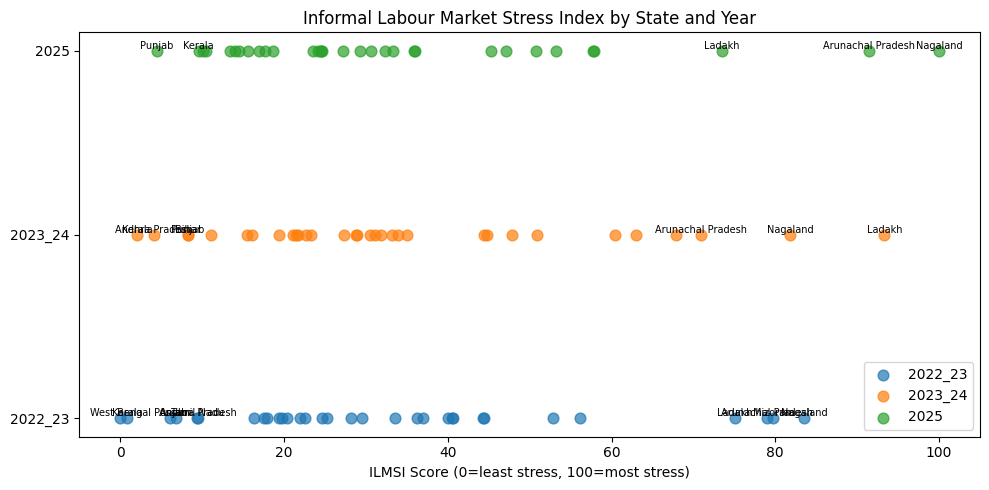

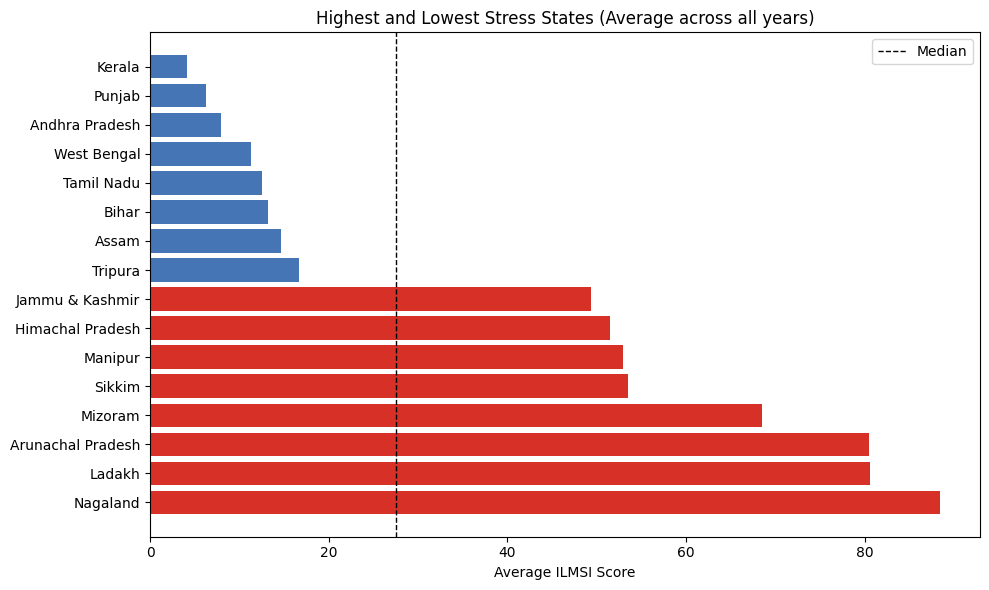

Plots saved.


In [207]:

import matplotlib.pyplot as plt
import matplotlib.cm as cm

# --- Plot 1: ILMSI distribution by year ---
fig, ax = plt.subplots(figsize=(10, 5))
for year, grp in df_index.groupby('year'):
    ax.scatter(grp['ILMSI'], [year]*len(grp), alpha=0.7, s=60, label=year)
    for _, row in grp.iterrows():
        if row['ILMSI'] > 70 or row['ILMSI'] < 10:
            ax.annotate(row['state'], (row['ILMSI'], year),
                        fontsize=7, ha='center', va='bottom')

ax.set_xlabel("ILMSI Score (0=least stress, 100=most stress)")
ax.set_title("Informal Labour Market Stress Index by State and Year")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE, "ilmsi_scatter.png"), dpi=150)
plt.show()

# --- Plot 2: Top and bottom 8 states (latest year average) ---
avg_by_state = df_index.groupby('state')['ILMSI'].mean().sort_values(ascending=False)
top8 = avg_by_state.head(8)
bot8 = avg_by_state.tail(8)
plot_data = pd.concat([top8, bot8])

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d73027' if v > avg_by_state.median() else '#4575b4' for v in plot_data.values]
ax.barh(plot_data.index, plot_data.values, color=colors)
ax.axvline(avg_by_state.median(), color='black', linestyle='--', linewidth=1, label='Median')
ax.set_xlabel("Average ILMSI Score")
ax.set_title("Highest and Lowest Stress States (Average across all years)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE, "ilmsi_bar.png"), dpi=150)
plt.show()

print("Plots saved.")

In [208]:
# Check correlations between index components and ILMSI
import pandas as pd
import numpy as np

corr_check = df_index[[ 'wage_precarity', 
                         'informality', 'casual_share', 
                         'self_reg_ratio', 'ILMSI']].corr()

print("Correlations with ILMSI:")
print(corr_check['ILMSI'].sort_values())

print("\nCorrelation matrix between components:")
cols = ['wage_precarity', 'informality', 'casual_share', 'self_reg_ratio']
print(corr_check.loc[cols, cols].round(3))

Correlations with ILMSI:
casual_share     -0.684605
informality      -0.523967
wage_precarity    0.771925
self_reg_ratio    0.799090
ILMSI             1.000000
Name: ILMSI, dtype: float64

Correlation matrix between components:
                wage_precarity  informality  casual_share  self_reg_ratio
wage_precarity           1.000       -0.179        -0.293           0.576
informality             -0.179        1.000         0.322          -0.193
casual_share            -0.293        0.322         1.000          -0.344
self_reg_ratio           0.576       -0.193        -0.344           1.000


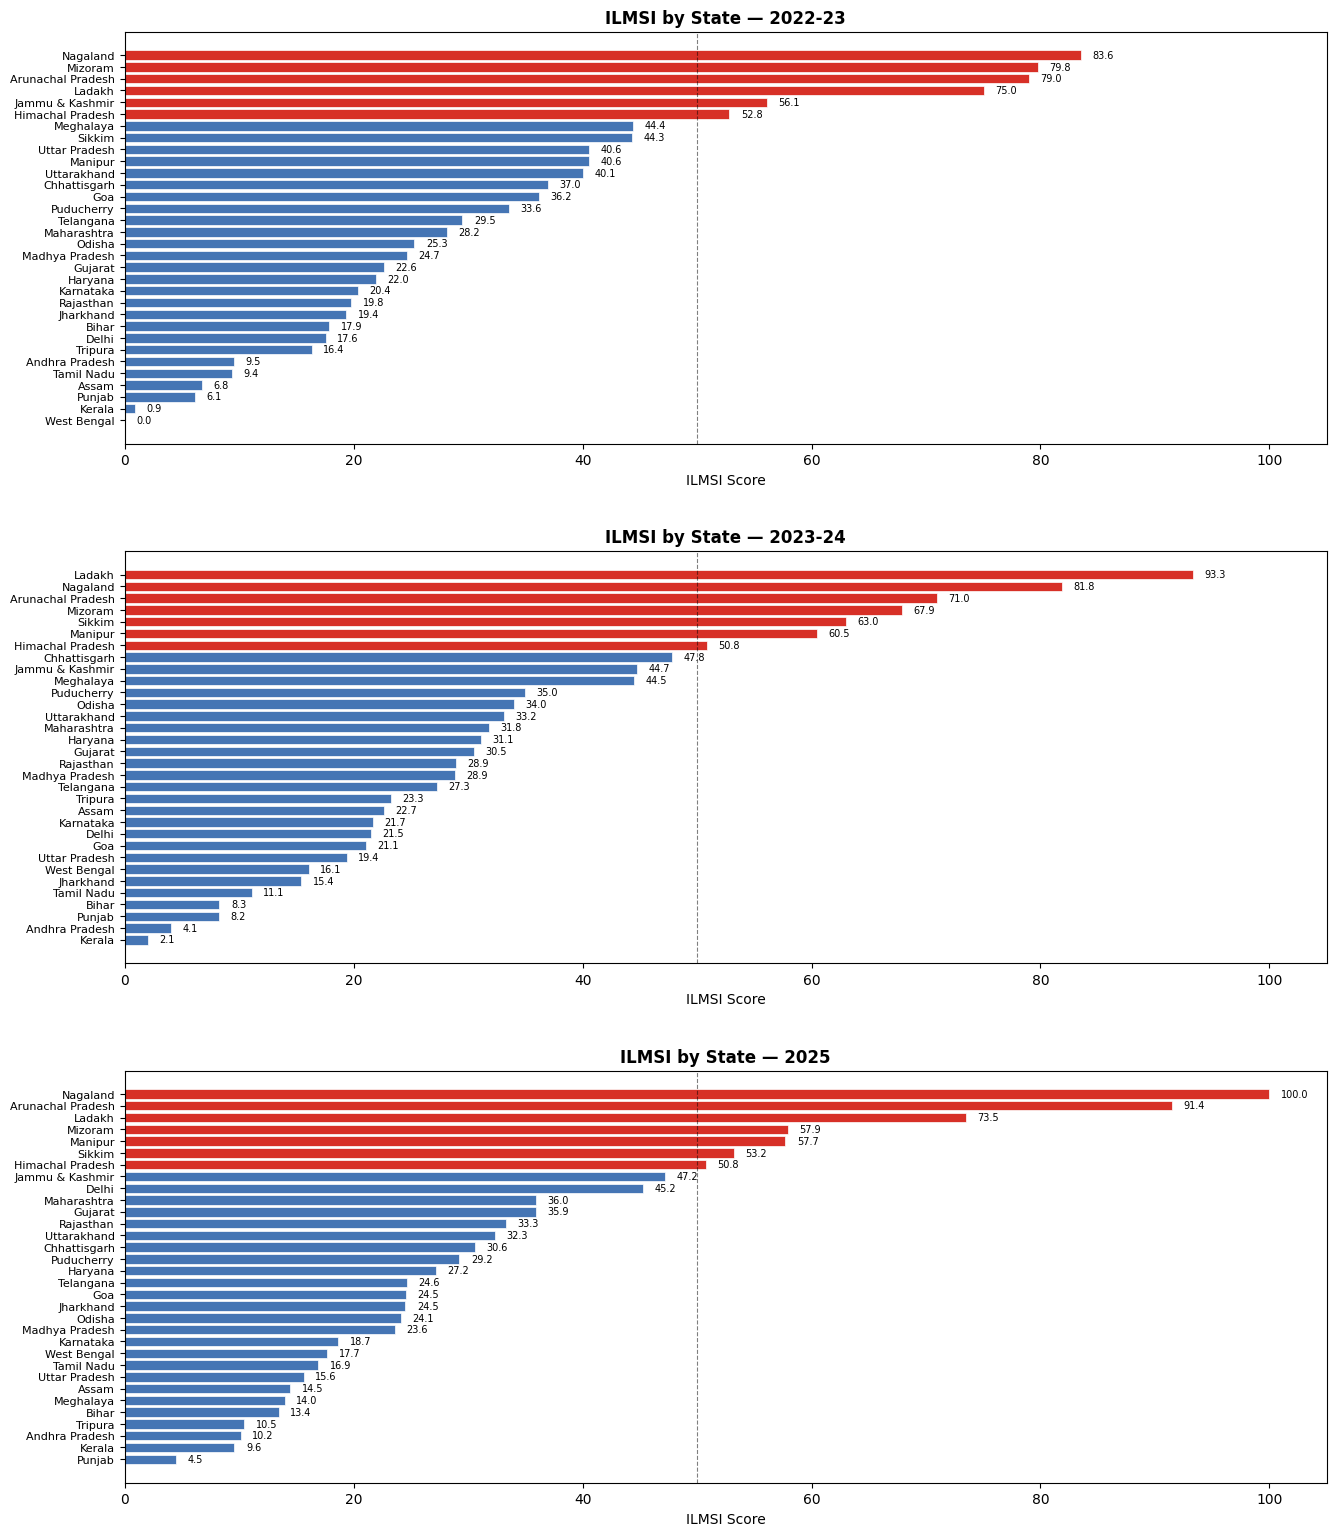

Saved.


In [209]:
import matplotlib.pyplot as plt
import numpy as np

years = df_index['year'].unique()
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

for ax, year in zip(axes, sorted(years)):
    subset = df_index[df_index['year'] == year].sort_values('ILMSI')
    
    colors = ['#d73027' if v > 50 else '#4575b4' for v in subset['ILMSI']]
    
    bars = ax.barh(subset['state'], subset['ILMSI'], 
                   color=colors, edgecolor='white', linewidth=0.5)
    
    ax.axvline(50, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlim(0, 105)
    ax.set_xlabel("ILMSI Score", fontsize=10)
    ax.set_title(f"ILMSI by State — {year.replace('_', '-')}", 
                 fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)
    
    # Add value labels
    for bar, val in zip(bars, subset['ILMSI']):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2, 
                f'{val:.1f}', va='center', fontsize=7)

plt.tight_layout(pad=3.0)
plt.savefig(os.path.join(BASE, "ilmsi_by_year.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [210]:
##PCA CHANGE

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Drop missing rows
df_index = df.dropna(subset=index_vars).copy()

X = df_index[index_vars].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run PCA
pca = PCA(n_components=1)
principal_component = pca.fit_transform(X_scaled)

# Store index
df_index['ILMSI'] = principal_component[:, 0]

In [211]:
# Explained variance
print("Explained variance (PC1):", pca.explained_variance_ratio_[0])

# Loadings
loadings = pd.Series(
    pca.components_[0],
    index=index_vars
)

print("\nPCA Loadings:")
print(loadings.sort_values(ascending=False))

Explained variance (PC1): 0.4944097408383482

PCA Loadings:
self_reg_ratio    0.568227
wage_precarity    0.548911
informality      -0.372589
casual_share     -0.486818
dtype: float64


# *Index Subsplit into EGI and SII*

In [212]:
#Cell 6 variable construction

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import numpy as np

# Drop small UTs with unreliable PLFS sample sizes
small_uts = ['Lakshadweep', 'Dadra & Nagar Haveli & Daman & Diu',
             'Andaman & N. Island', 'Chandigarh']
df = master_wide[~master_wide['state'].isin(small_uts)].copy()

# --- Variable construction ---

# Earnings Gap variables (both: higher = more stress)
df['wage_precarity'] =  df['WAGE REGULAR'] / (df['WAGE CASUAL'] * 30) 
df['self_reg_ratio']  = df['WAGE REGULAR'] / df['WAGE SELF']

# Structural Informality variables (both: higher = more stress)
df['casual_share'] = df['EMP STATUS']
df['informality']  = df['ENTERPRISE']

df_index = df[['state', 'year',
               'wage_precarity', 'self_reg_ratio',
               'casual_share', 'informality']].dropna()

print(f"Dataset shape: {df_index.shape}")
print(f"States: {df_index['state'].nunique()}")
print(f"\nDescriptive stats:")
print(df_index[['wage_precarity','self_reg_ratio',
                'casual_share','informality']].describe().round(3))

Dataset shape: (96, 6)
States: 32

Descriptive stats:
       wage_precarity  self_reg_ratio  casual_share  informality
count          96.000          96.000        96.000       96.000
mean            1.430           1.641        17.244       67.528
std             0.369           0.700         8.124       12.114
min             0.769           0.506         4.300       37.500
25%             1.178           1.206         9.775       59.350
50%             1.370           1.473        17.900       68.500
75%             1.636           1.908        23.025       76.725
max             2.932           4.527        39.100       89.400


In [213]:
#Cell 7: Build both sub-indices and composite
def build_subindex(df, vars, name, negate_if_needed=True):
    """
    Standardise variables, run PCA, extract PC1, rescale to 0-100.
    Automatically orients so that higher score = more stress.
    """
    scaler = StandardScaler()
    X = scaler.fit_transform(df[vars].values)
    
    pca = PCA(n_components=1)
    scores = pca.fit_transform(X).flatten()
    
    # Check orientation: if PC1 negatively correlates with first var, flip
    if np.corrcoef(scores, df[vars[0]].values)[0,1] < 0:
        scores = -scores
    
    # Rescale to 0-100
    scores = (scores - scores.min()) / (scores.max() - scores.min()) * 100
    
    print(f"\n{name}")
    print(f"  PC1 variance explained: {pca.explained_variance_ratio_[0]:.3f}")
    print(f"  Loadings:")
    for v, l in zip(vars, pca.components_[0]):
        # Adjust sign for display if we flipped
        corr_sign = np.sign(np.corrcoef(scores, df[v].values)[0,1])
        print(f"    {v:20s}: {l * corr_sign:+.3f}")
    
    return scores

# Build sub-indices
df_index = df_index.copy()

df_index['EGI'] = build_subindex(
    df_index,
    ['wage_precarity', 'self_reg_ratio'],
    "Earnings Gap Index (EGI)"
)

df_index['SII'] = build_subindex(
    df_index,
    ['casual_share', 'informality'],
    "Structural Informality Index (SII)"
)

# Composite: simple average of both sub-indices
df_index['ILMSI'] = (df_index['EGI'] + df_index['SII']) / 2

print(f"\n--- Composite ILMSI (average of EGI and SII) ---")
print(f"\nTop 10 highest stress:")
print(df_index[['state','year','EGI','SII','ILMSI']]
      .sort_values('ILMSI', ascending=False).head(10).to_string())
print(f"\nTop 10 lowest stress:")
print(df_index[['state','year','EGI','SII','ILMSI']]
      .sort_values('ILMSI').head(10).to_string())

# Save
index_path = os.path.join(BASE, "plfs_ilmsi.csv")
df_index.to_csv(index_path, index=False)
print(f"\nSaved: {index_path}")


Earnings Gap Index (EGI)
  PC1 variance explained: 0.788
  Loadings:
    wage_precarity      : +0.707
    self_reg_ratio      : +0.707

Structural Informality Index (SII)
  PC1 variance explained: 0.661
  Loadings:
    casual_share        : +0.707
    informality         : +0.707

--- Composite ILMSI (average of EGI and SII) ---

Top 10 highest stress:
              state     year         EGI         SII      ILMSI
76           Odisha  2023_24   54.426295   84.692051  69.559173
52           Ladakh  2023_24  100.000000   38.872790  69.436395
12            Bihar  2022_23   40.950613   95.859438  68.405025
51           Ladakh  2022_23   84.045197   49.558085  66.801641
9             Assam  2022_23   30.230898  100.000000  65.115449
19     Chhattisgarh  2023_24   61.718935   68.188301  64.953618
99    Uttar Pradesh  2022_23   53.485465   71.810566  62.648015
75           Odisha  2022_23   41.438969   81.759109  61.599039
14            Bihar     2025   30.895320   89.950312  60.422816
39  

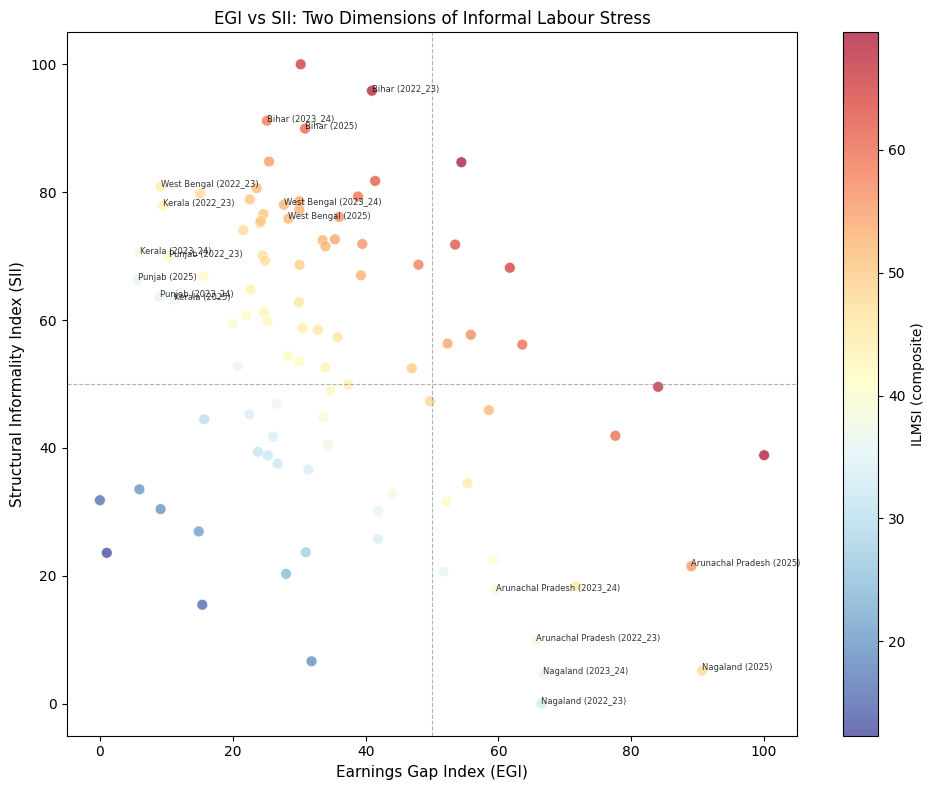

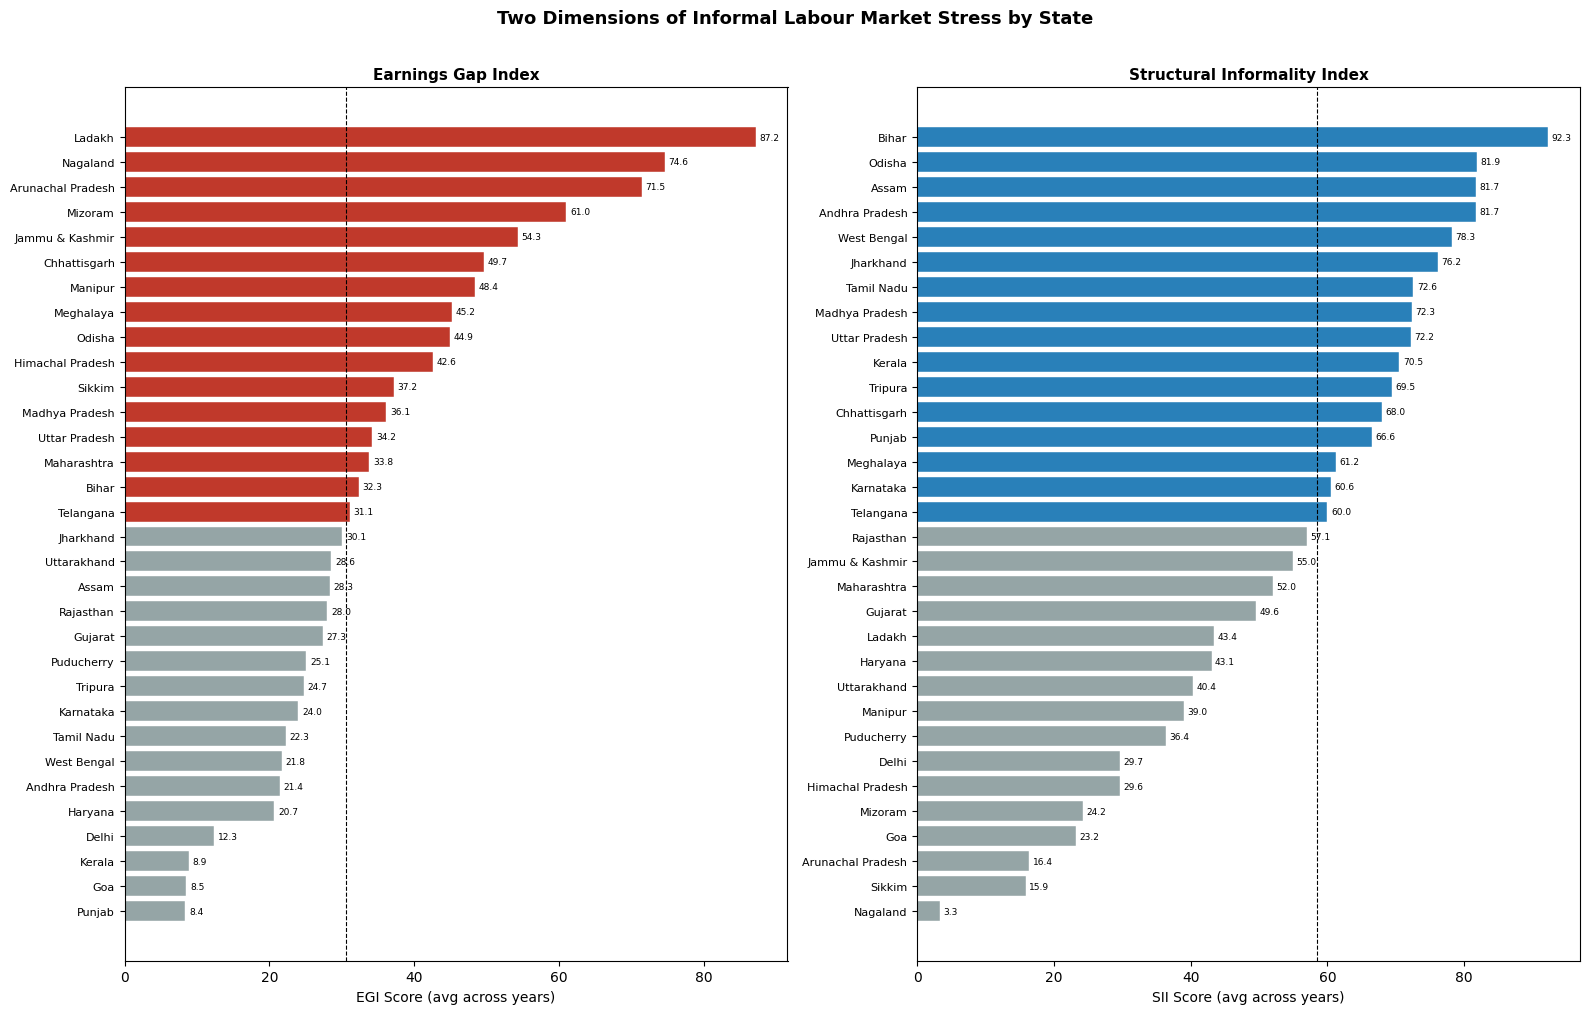

In [214]:
#Cell 8: Visualisation 
import matplotlib.pyplot as plt

years = sorted(df_index['year'].unique())
avg = df_index.groupby('state')[['EGI','SII','ILMSI']].mean().sort_values('ILMSI')

# --- Chart 1: EGI vs SII scatter (all state-years) ---
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(df_index['EGI'], df_index['SII'],
                     c=df_index['ILMSI'], cmap='RdYlBu_r',
                     s=60, alpha=0.7, edgecolors='white', linewidth=0.5)
plt.colorbar(scatter, label='ILMSI (composite)')
ax.axvline(50, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(50, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel("Earnings Gap Index (EGI)", fontsize=11)
ax.set_ylabel("Structural Informality Index (SII)", fontsize=11)
ax.set_title("EGI vs SII: Two Dimensions of Informal Labour Stress", fontsize=12)

# Label a few key states
for _, row in df_index.iterrows():
    if row['state'] in ['Kerala', 'Punjab', 'Bihar', 'Nagaland',
                        'West Bengal', 'Arunachal Pradesh']:
        ax.annotate(f"{row['state']} ({row['year']})",
                    (row['EGI'], row['SII']),
                    fontsize=6, alpha=0.8)

plt.tight_layout()
plt.savefig(os.path.join(BASE, "egi_vs_sii.png"), dpi=150, bbox_inches='tight')
plt.show()

# --- Chart 2: Side by side EGI and SII bar charts (average across years) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

for ax, col, title, color_high in zip(
    axes,
    ['EGI', 'SII'],
    ['Earnings Gap Index', 'Structural Informality Index'],
    ['#c0392b', '#2980b9']
):
    data = df_index.groupby('state')[col].mean().sort_values()
    colors = [color_high if v > data.median() else '#95a5a6' for v in data.values]
    bars = ax.barh(data.index, data.values, color=colors, edgecolor='white', linewidth=0.3)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=0.8)
    ax.set_xlabel(f"{col} Score (avg across years)", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)
    for bar, val in zip(bars, data.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=6.5)

plt.suptitle("Two Dimensions of Informal Labour Market Stress by State",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "egi_sii_bars.png"), dpi=150, bbox_inches='tight')
plt.show()



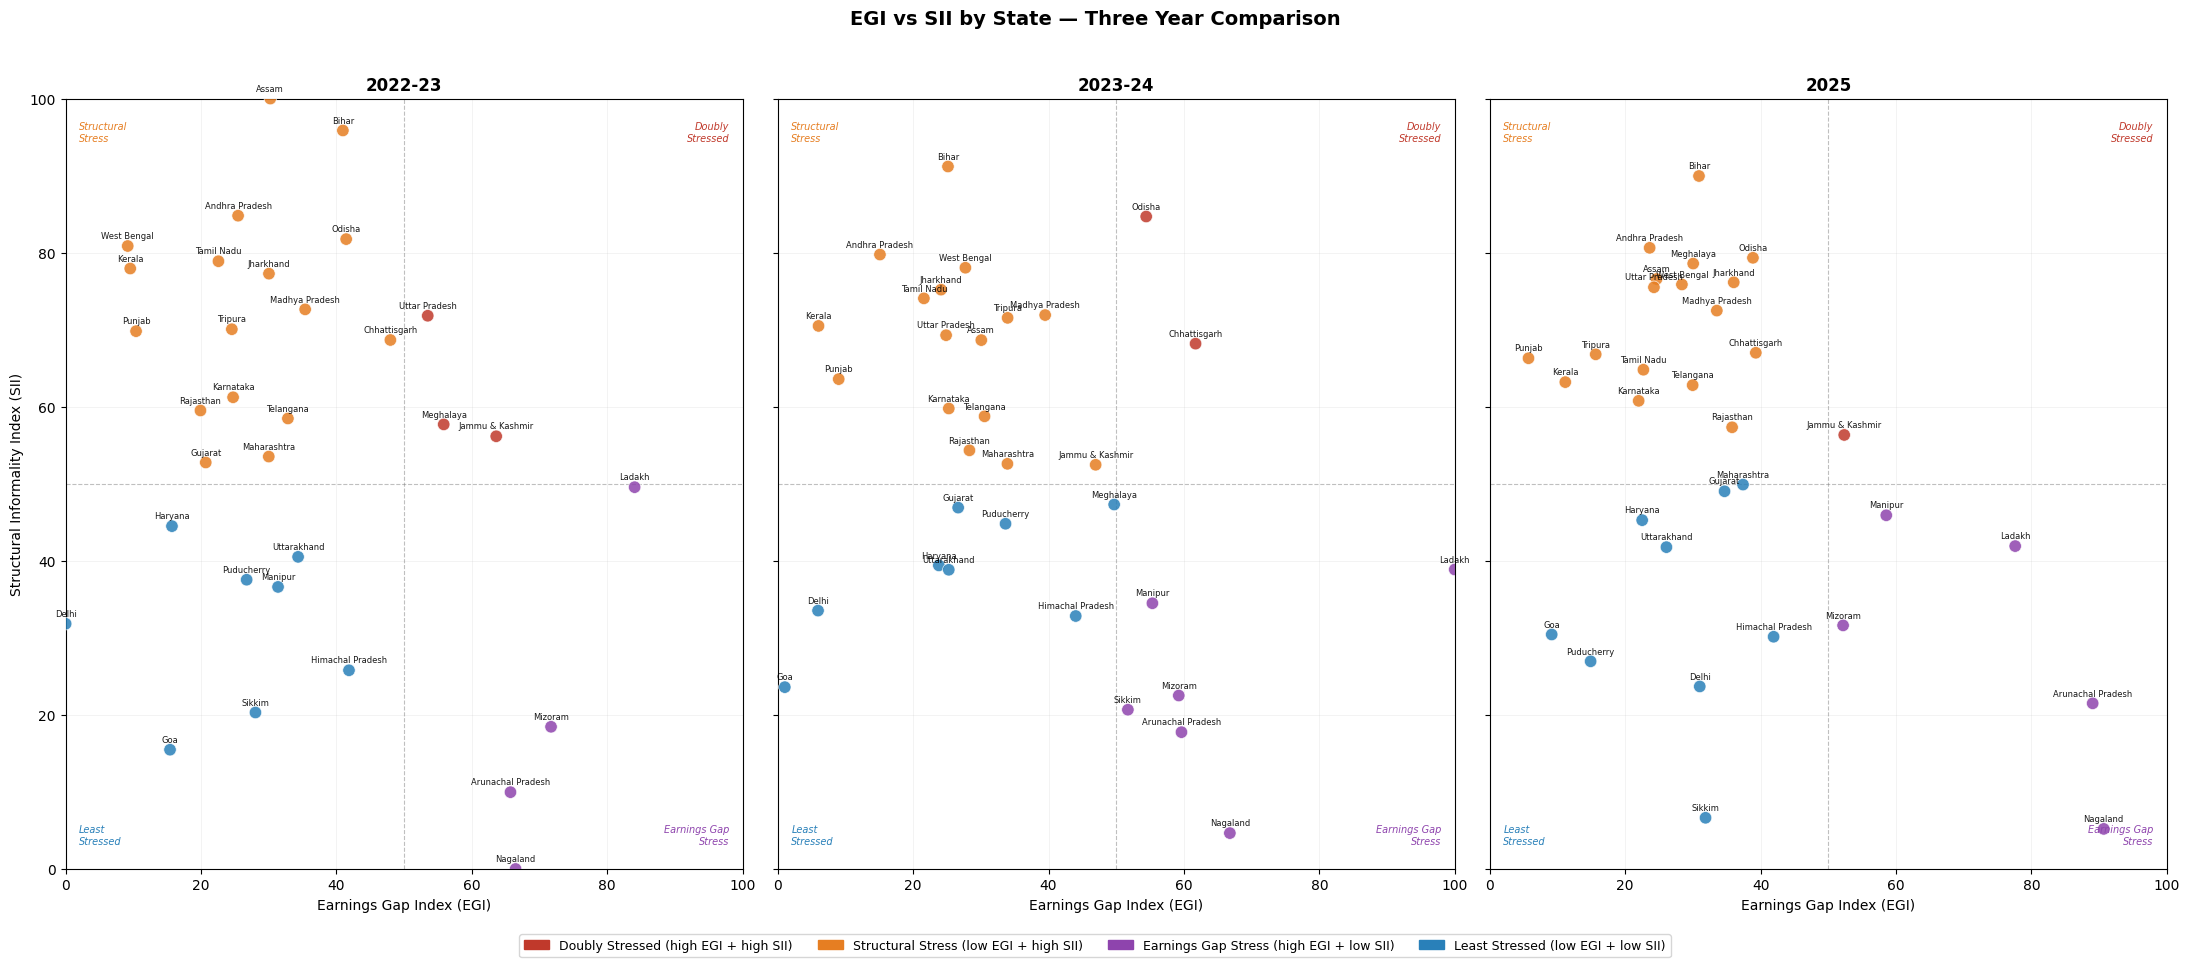

Saved.


In [215]:
#Plot for all three years, each point labelled
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

years = sorted(df_index['year'].unique())
fig, axes = plt.subplots(1, 3, figsize=(22, 9), sharey=True, sharex=True)

for ax, year in zip(axes, years):
    subset = df_index[df_index['year'] == year].copy()
    
    # Color by quadrant
    colors = []
    for _, row in subset.iterrows():
        if row['EGI'] >= 50 and row['SII'] >= 50:
            colors.append('#c0392b')    # top right: doubly stressed
        elif row['EGI'] < 50 and row['SII'] >= 50:
            colors.append('#e67e22')    # top left: structural stress
        elif row['EGI'] >= 50 and row['SII'] < 50:
            colors.append('#8e44ad')    # bottom right: earnings gap stress
        else:
            colors.append('#2980b9')    # bottom left: least stressed
    
    ax.scatter(subset['EGI'], subset['SII'],
               c=colors, s=80, alpha=0.85,
               edgecolors='white', linewidth=0.5, zorder=3)
    
    # Label every point
    for _, row in subset.iterrows():
        ax.annotate(
            row['state'],
            (row['EGI'], row['SII']),
            fontsize=6,
            ha='center',
            va='bottom',
            xytext=(0, 4),
            textcoords='offset points',
            alpha=0.9
        )
    
    # Quadrant lines
    ax.axvline(50, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(50, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Quadrant labels
    ax.text(2, 97, 'Structural\nStress', fontsize=7, color='#e67e22',
            va='top', style='italic')
    ax.text(98, 97, 'Doubly\nStressed', fontsize=7, color='#c0392b',
            va='top', ha='right', style='italic')
    ax.text(2, 3, 'Least\nStressed', fontsize=7, color='#2980b9',
            va='bottom', style='italic')
    ax.text(98, 3, 'Earnings Gap\nStress', fontsize=7, color='#8e44ad',
            va='bottom', ha='right', style='italic')
    
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_xlabel("Earnings Gap Index (EGI)", fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel("Structural Informality Index (SII)", fontsize=10)
    ax.set_title(f"{year.replace('_', '-')}", fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.2, linewidth=0.5)

# Legend
patches = [
    mpatches.Patch(color='#c0392b', label='Doubly Stressed (high EGI + high SII)'),
    mpatches.Patch(color='#e67e22', label='Structural Stress (low EGI + high SII)'),
    mpatches.Patch(color='#8e44ad', label='Earnings Gap Stress (high EGI + low SII)'),
    mpatches.Patch(color='#2980b9', label='Least Stressed (low EGI + low SII)'),
]
fig.legend(handles=patches, loc='lower center', ncol=4,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.04))

plt.suptitle("EGI vs SII by State — Three Year Comparison",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "egi_sii_by_year.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

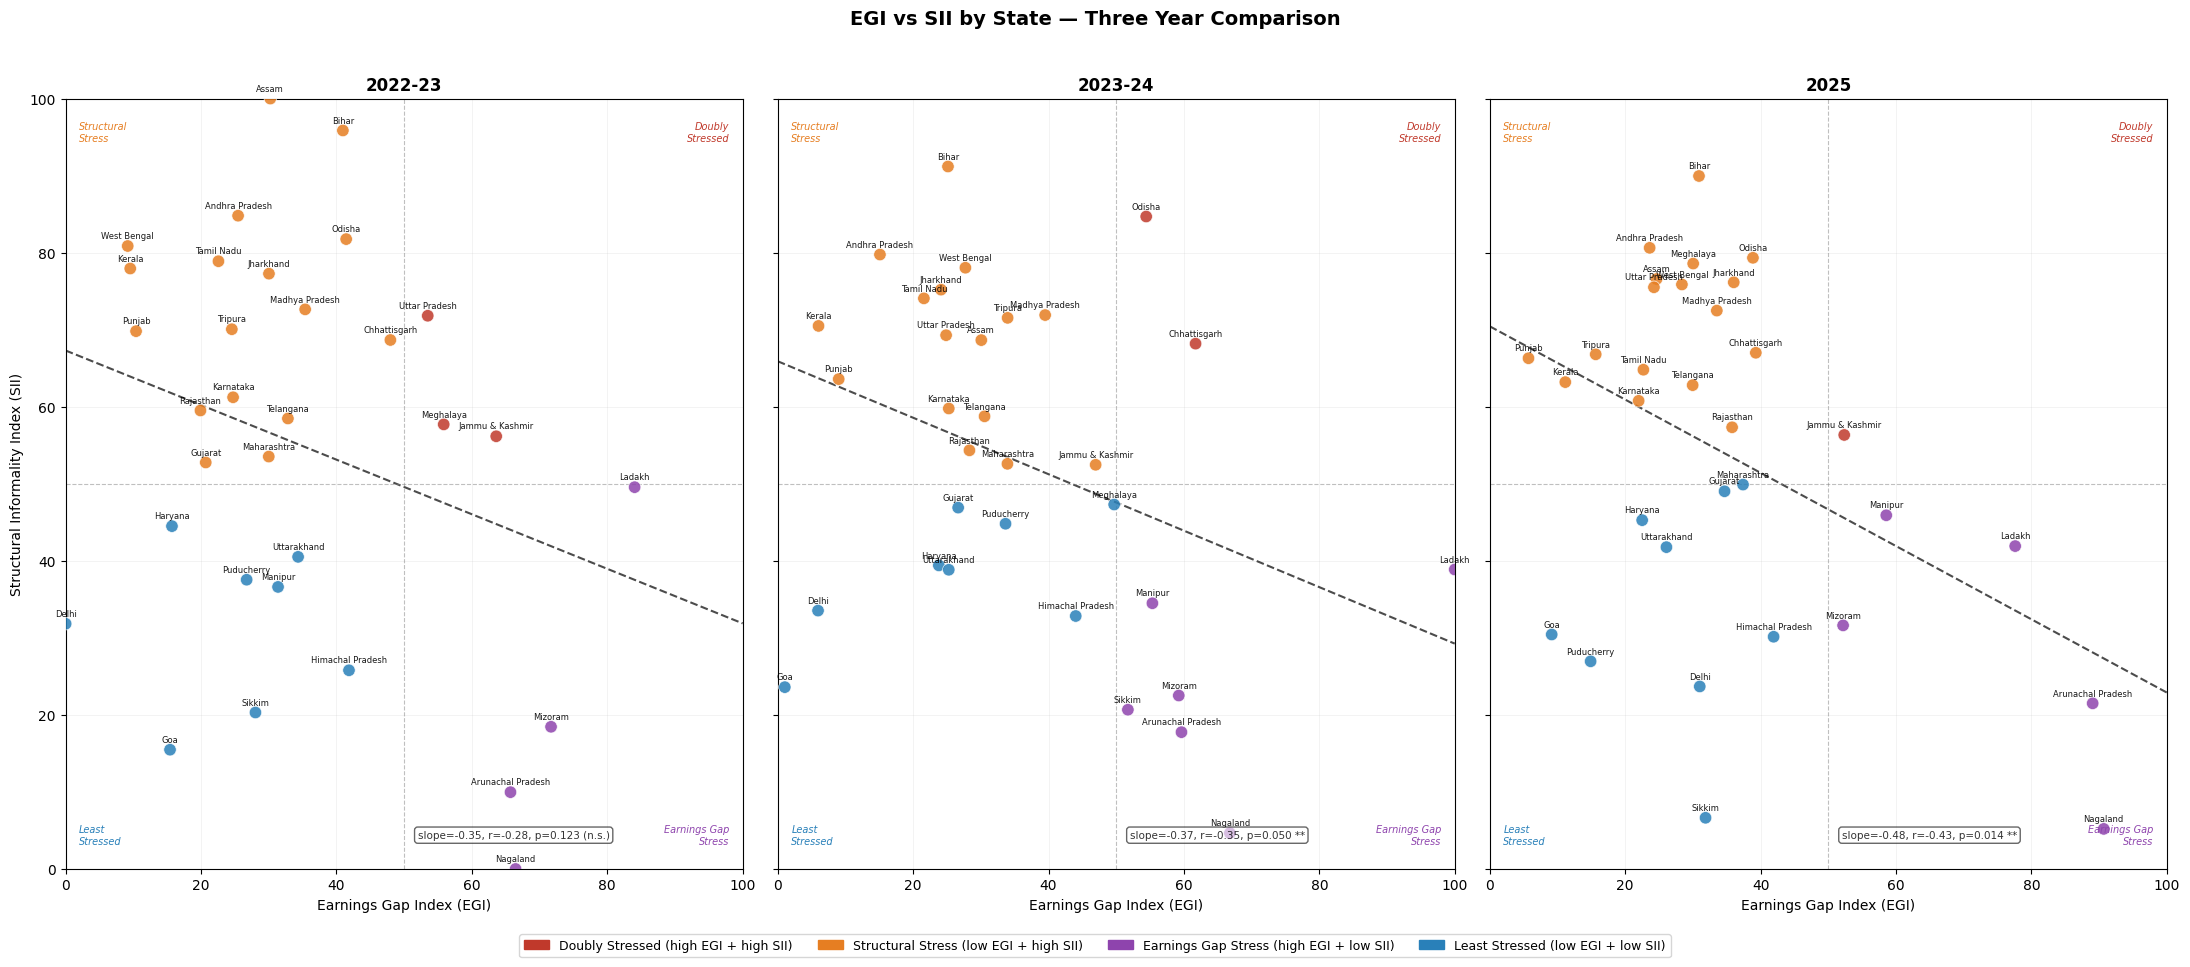

Saved.


In [216]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats

years = sorted(df_index['year'].unique())
fig, axes = plt.subplots(1, 3, figsize=(22, 9), sharey=True, sharex=True)

for ax, year in zip(axes, years):
    subset = df_index[df_index['year'] == year].copy()
    
    # Color by quadrant
    colors = []
    for _, row in subset.iterrows():
        if row['EGI'] >= 50 and row['SII'] >= 50:
            colors.append('#c0392b')
        elif row['EGI'] < 50 and row['SII'] >= 50:
            colors.append('#e67e22')
        elif row['EGI'] >= 50 and row['SII'] < 50:
            colors.append('#8e44ad')
        else:
            colors.append('#2980b9')
    
    ax.scatter(subset['EGI'], subset['SII'],
               c=colors, s=80, alpha=0.85,
               edgecolors='white', linewidth=0.5, zorder=3)
    
    # Label every point
    for _, row in subset.iterrows():
        ax.annotate(
            row['state'],
            (row['EGI'], row['SII']),
            fontsize=6,
            ha='center',
            va='bottom',
            xytext=(0, 4),
            textcoords='offset points',
            alpha=0.9
        )
    
    # --- Trendline ---
    x = subset['EGI'].values
    y = subset['SII'].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    x_line = np.linspace(0, 100, 200)
    y_line = slope * x_line + intercept
    # Only draw where y_line is within bounds
    mask = (y_line >= 0) & (y_line <= 100)
    sig_label = '***' if p_value < 0.01 else '**' if p_value < 0.05 else '*' if p_value < 0.1 else '(n.s.)'
    ax.plot(x_line[mask], y_line[mask],
            color='black', linewidth=1.5, linestyle='--', alpha=0.7, zorder=2)
    ax.text(52, 4,
            f'slope={slope:.2f}, r={r_value:.2f}, p={p_value:.3f} {sig_label}',
            fontsize=7.5, color='black', alpha=0.8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.6))
    
    # Quadrant lines
    ax.axvline(50, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(50, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # Quadrant labels
    ax.text(2, 97, 'Structural\nStress', fontsize=7, color='#e67e22',
            va='top', style='italic')
    ax.text(98, 97, 'Doubly\nStressed', fontsize=7, color='#c0392b',
            va='top', ha='right', style='italic')
    ax.text(2, 3, 'Least\nStressed', fontsize=7, color='#2980b9',
            va='bottom', style='italic')
    ax.text(98, 3, 'Earnings Gap\nStress', fontsize=7, color='#8e44ad',
            va='bottom', ha='right', style='italic')
    
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_xlabel("Earnings Gap Index (EGI)", fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel("Structural Informality Index (SII)", fontsize=10)
    ax.set_title(f"{year.replace('_', '-')}", fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.2, linewidth=0.5)

# Legend
patches = [
    mpatches.Patch(color='#c0392b', label='Doubly Stressed (high EGI + high SII)'),
    mpatches.Patch(color='#e67e22', label='Structural Stress (low EGI + high SII)'),
    mpatches.Patch(color='#8e44ad', label='Earnings Gap Stress (high EGI + low SII)'),
    mpatches.Patch(color='#2980b9', label='Least Stressed (low EGI + low SII)'),
]
fig.legend(handles=patches, loc='lower center', ncol=4,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.04))

plt.suptitle("EGI vs SII by State — Three Year Comparison",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "egi_sii_trendlines.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [217]:
import pandas as pd

lit = pd.read_excel(r"C:\Projects\PLFS\Table29.6-States.xlsx")

# Keep needed columns
lit = lit[[
    'All India/State/Union Territory',
    '2011 - Rural - Person',
    '2011 - Urban - Persons'
]]

# Rename
lit = lit.rename(columns={
    'All India/State/Union Territory': 'state',
    '2011 - Rural - Person': 'lit_rural',
    '2011 - Urban - Persons': 'lit_urban'
})

print(lit.head())

               state  lit_rural  lit_urban
0          All India         68         84
1     Andhra Pradesh         60         80
2  Arunachal Pradesh         60         83
3              Assam         69         89
4              Bihar         60         77


In [218]:
lit['literacy'] = (lit['lit_rural'] + lit['lit_urban']) / 2

In [219]:
# Drop All India
lit = lit[lit['state'] != 'All India']

# Clean state names
lit['state'] = lit['state'].str.strip()

lit = lit[['state', 'literacy']].reset_index(drop=True)

print(lit.head())

               state  literacy
0     Andhra Pradesh      70.0
1  Arunachal Pradesh      71.5
2              Assam      79.0
3              Bihar      68.5
4        Chhatisgarh      75.0


In [220]:
state_map = {
    "Jammu & Kashmir": "Jammu and Kashmir",
    "A. and N. Islands": "A & N Islands",
    "Daman and Diu": "Daman & Diu",
}

lit['state'] = lit['state'].replace(state_map)
df_index['state'] = df_index['state'].replace(state_map)

In [221]:
df = df_index.merge(lit, on='state', how='left')

print(df[['state', 'literacy']].head(20))

                state  literacy
0      Andhra Pradesh      70.0
1      Andhra Pradesh      70.0
2      Andhra Pradesh      70.0
3   Arunachal Pradesh      71.5
4   Arunachal Pradesh      71.5
5   Arunachal Pradesh      71.5
6               Assam      79.0
7               Assam      79.0
8               Assam      79.0
9               Bihar      68.5
10              Bihar      68.5
11              Bihar      68.5
12       Chhattisgarh       NaN
13       Chhattisgarh       NaN
14       Chhattisgarh       NaN
15              Delhi      84.0
16              Delhi      84.0
17              Delhi      84.0
18                Goa      88.5
19                Goa      88.5


In [222]:
state_map_extra = {
    "Chhattisgarh": "Chhatisgarh",   # sometimes spelled differently
    "Uttarakhand": "Uttaranchal",
    "Telangana": "Andhra Pradesh",  # Telangana didn't exist in 2011
    "Ladakh": "Jammu and Kashmir"   # same reason
}

df['state'] = df['state'].replace(state_map_extra)

In [223]:
# Clean INDUSTRY table

ind = pd.read_excel(r"C:\Projects\PLFS\PLFS 23-24 tables\PLFS 23-24 INDUSTRY.xlsx")

# Drop top junk rows
ind_clean = ind.iloc[6:].copy()

# Rename columns
ind_clean.columns = ['state'] + [f'col_{i}' for i in range(1, len(ind_clean.columns))]

# Drop empty rows
ind_clean = ind_clean[ind_clean['state'].notna()]

# Strip state names
ind_clean['state'] = ind_clean['state'].str.strip()

# Agriculture = first column after state
# Agriculture = first column after state
ind_clean['agri_share'] = ind_clean['col_1']

# Convert to numeric (CRITICAL FIX)
ind_clean['agri_share'] = pd.to_numeric(ind_clean['agri_share'], errors='coerce')

# Drop missing values
ind_clean = ind_clean[ind_clean['agri_share'].notna()]

# Keep only needed columns
agri = ind_clean[['state', 'agri_share']]

print(agri.head())
print(agri['agri_share'].describe())

                state  agri_share
6      Andhra Pradesh       53.50
7   Arunachal Pradesh       58.85
8               Assam       34.47
9               Bihar       46.25
10       Chhattisgarh       65.59
count    330.000000
mean      33.937394
std       25.181907
min        0.000000
25%        8.912500
50%       33.895000
75%       53.895000
max       88.650000
Name: agri_share, dtype: float64


In [224]:
agri = agri.groupby('state', as_index=False)['agri_share'].mean()

In [225]:
# Convert to numeric
ind_clean['agri_share'] = pd.to_numeric(ind_clean['col_1'], errors='coerce')

# Drop NA
ind_clean = ind_clean[ind_clean['agri_share'].notna()]

# Keep only needed columns
agri = ind_clean[['state', 'agri_share']]

# Aggregate to one value per state
agri = agri.groupby('state', as_index=False)['agri_share'].mean()

print(agri.head())
print(agri['agri_share'].describe())

                 state  agri_share
0  Andaman & N. Island   26.520000
1       Andhra Pradesh   38.943333
2    Arunachal Pradesh   50.263333
3                Assam   38.455556
4                Bihar   46.822222
count    37.000000
mean     33.631652
std      12.618750
min       0.000000
25%      27.590000
50%      38.301111
75%      39.963333
max      51.406667
Name: agri_share, dtype: float64


In [226]:
agri = agri[agri['agri_share'] > 0]

In [227]:
df = df.merge(agri, on='state', how='left')

In [228]:
df_reg = df[['SII', 'agri_share', 'literacy']].dropna()

In [229]:
import statsmodels.api as sm
X = df_reg[['agri_share', 'literacy']]
X = sm.add_constant(X)

y = df_reg['SII']

model_sii = sm.OLS(y, X).fit()
print(model_sii.summary())

                            OLS Regression Results                            
Dep. Variable:                    SII   R-squared:                       0.178
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     8.437
Date:                Sat, 09 May 2026   Prob (F-statistic):           0.000482
Time:                        20:57:26   Log-Likelihood:                -366.86
No. Observations:                  81   AIC:                             739.7
Df Residuals:                      78   BIC:                             746.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        160.1862     40.361      3.969      0.0

In [230]:
df[['SII', 'agri_share']].corr()

,SII,agri_share
SII,1.000000,0.267857
agri_share,0.267857,1.000000


In [231]:
# Urbanisation rate by state — from PLFS Table 1 or Census
# Use the urban share of population from your existing LFPR file
# as a proxy: urban LFPR observations / total observations
# OR simply add urbanisation data manually from Census 2011 
# (stable enough for a cross-sectional validation)

urban_rates = {
    'Andhra Pradesh': 29.6, 'Arunachal Pradesh': 22.7, 'Assam': 14.1,
    'Bihar': 11.3, 'Chhattisgarh': 23.2, 'Delhi': 97.5, 'Goa': 62.2,
    'Gujarat': 42.6, 'Haryana': 34.9, 'Himachal Pradesh': 10.0,
    'Jammu & Kashmir': 27.4, 'Jharkhand': 24.1, 'Karnataka': 38.6,
    'Kerala': 47.7, 'Madhya Pradesh': 27.6, 'Maharashtra': 45.2,
    'Manipur': 30.2, 'Meghalaya': 20.1, 'Mizoram': 52.1,
    'Nagaland': 28.9, 'Odisha': 16.7, 'Punjab': 37.5,
    'Rajasthan': 24.9, 'Sikkim': 25.2, 'Tamil Nadu': 48.4,
    'Telangana': 38.9, 'Tripura': 26.2, 'Uttar Pradesh': 22.3,
    'Uttarakhand': 30.2, 'West Bengal': 31.9, 'Puducherry': 68.3,
    'Ladakh': 28.0
}

urban_df = pd.DataFrame(list(urban_rates.items()), 
                         columns=['state', 'urban_rate'])

# Average EGI per state across years for cross-sectional validation
egi_avg = df_index.groupby('state')['EGI'].mean().reset_index()
egi_val = egi_avg.merge(urban_df, on='state')

import statsmodels.api as sm
X = sm.add_constant(egi_val[['urban_rate']])
y = egi_val['EGI']
model_egi_valid = sm.OLS(y, X).fit()
print(model_egi_valid.summary())

print(f"\nCorrelation: {egi_val[['EGI','urban_rate']].corr().iloc[0,1]:.3f}")

                            OLS Regression Results                            
Dep. Variable:                    EGI   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     5.116
Date:                Sat, 09 May 2026   Prob (F-statistic):             0.0314
Time:                        20:57:26   Log-Likelihood:                -132.28
No. Observations:                  31   AIC:                             268.6
Df Residuals:                      29   BIC:                             271.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         48.4630      6.947      6.976      0.0

# Validating further using GVA and NREGA card holding data for SII and EGI 

In [232]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import os

BASE = r"C:\Projects\PLFS"

# ── GVA per capita (complete block) ──────────────────────────────────

# Population (Census 2011, in lakhs)
state_population = {
    'Andhra Pradesh': 492.4, 'Arunachal Pradesh': 13.8, 'Assam': 312.1,
    'Bihar': 1040.9, 'Chhattisgarh': 255.5, 'Delhi': 167.5, 'Goa': 14.6,
    'Gujarat': 604.4, 'Haryana': 253.5, 'Himachal Pradesh': 68.6,
    'Jammu & Kashmir': 125.4, 'Jharkhand': 329.9, 'Karnataka': 610.1,
    'Kerala': 333.4, 'Madhya Pradesh': 724.6, 'Maharashtra': 1123.7,
    'Manipur': 28.6, 'Meghalaya': 29.7, 'Mizoram': 10.9,
    'Nagaland': 19.8, 'Odisha': 419.7, 'Punjab': 277.4,
    'Rajasthan': 685.2, 'Sikkim': 6.1, 'Tamil Nadu': 721.5,
    'Telangana': 350.0, 'Tripura': 36.7, 'Uttar Pradesh': 1998.1,
    'Uttarakhand': 100.9, 'West Bengal': 912.8,
    'Puducherry': 12.5, 'Ladakh': 2.7
}
pop_df = pd.DataFrame(list(state_population.items()),
                      columns=['state', 'population_lakh'])

# Load GVA file
gva_raw = pd.read_excel(os.path.join(BASE, "gva.xlsx"),
                        sheet_name="T_26(ii)", header=None)
rows = gva_raw.values.tolist()
year_cols = rows[5][2:]

gva_data = []
for row in rows[6:39]:
    state = row[1]
    if not isinstance(state, str):
        continue
    if state.startswith('-') or state.startswith('Source'):
        continue
    entry = {'state': state.replace('*', '').strip()}
    for yr, val in zip(year_cols, row[2:]):
        if isinstance(yr, str) and yr != 'Base: 2011-12':
            entry[yr] = val if isinstance(val, (int, float)) else np.nan
    gva_data.append(entry)

gva = pd.DataFrame(gva_data)

# Per capita: GVA in lakh rupees / population in lakhs = rupees per person
gva_pc = gva[['state', '2022-23']].copy()
gva_pc.columns = ['state', 'gva_2022_23']
gva_pc = gva_pc.merge(pop_df, on='state', how='left')
gva_pc['gva_per_capita'] = gva_pc['gva_2022_23'] / gva_pc['population_lakh']

print("GVA per capita (Rs per person, 2022-23, constant prices):")
print(gva_pc[['state', 'gva_per_capita']]
      .sort_values('gva_per_capita', ascending=False).to_string())

# ── EGI validation regression ─────────────────────────────────────────
urban_rates = {
    'Andhra Pradesh': 29.6, 'Arunachal Pradesh': 22.7, 'Assam': 14.1,
    'Bihar': 11.3, 'Chhattisgarh': 23.2, 'Delhi': 97.5, 'Goa': 62.2,
    'Gujarat': 42.6, 'Haryana': 34.9, 'Himachal Pradesh': 10.0,
    'Jammu & Kashmir': 27.4, 'Jharkhand': 24.1, 'Karnataka': 38.6,
    'Kerala': 47.7, 'Madhya Pradesh': 27.6, 'Maharashtra': 45.2,
    'Manipur': 30.2, 'Meghalaya': 20.1, 'Mizoram': 52.1,
    'Nagaland': 28.9, 'Odisha': 16.7, 'Punjab': 37.5,
    'Rajasthan': 24.9, 'Sikkim': 25.2, 'Tamil Nadu': 48.4,
    'Telangana': 38.9, 'Tripura': 26.2, 'Uttar Pradesh': 22.3,
    'Uttarakhand': 30.2, 'West Bengal': 31.9, 'Puducherry': 68.3,
    'Ladakh': 28.0
}
urban_df = pd.DataFrame(list(urban_rates.items()),
                         columns=['state', 'urban_rate'])

# Average EGI per state across all years
egi_avg = df_index.groupby('state')['EGI'].mean().reset_index()

# Merge
egi_val = (egi_avg
    .merge(urban_df,  on='state', how='left')
    .merge(gva_pc[['state', 'gva_per_capita']], on='state', how='left')
)

print(f"\nEGI validation dataset shape: {egi_val.shape}")
print(f"Missing values:\n{egi_val.isnull().sum()}")

# Correlation check first
print(f"\nCorrelations:")
print(f"  EGI vs urban_rate:     {egi_val[['EGI','urban_rate']].corr().iloc[0,1]:+.3f}")
print(f"  EGI vs gva_per_capita: {egi_val[['EGI','gva_per_capita']].corr().iloc[0,1]:+.3f}")

# Regression
import statsmodels.api as sm

egi_data = egi_val[['EGI', 'urban_rate', 'gva_per_capita']].dropna()
X_egi = sm.add_constant(egi_data[['urban_rate', 'gva_per_capita']])
model_egi = sm.OLS(egi_data['EGI'], X_egi).fit()

print("\n" + "="*65)
print("VALIDATION REGRESSION: EGI ~ urban_rate + gva_per_capita")
print("="*65)
print(model_egi.summary())

GVA per capita (Rs per person, 2022-23, constant prices):
                        state  gva_per_capita
8                         Goa   370174.863014
26                     Sikkim   360043.606557
7                       Delhi   320711.158209
10                    Haryana   205881.420118
14                  Karnataka   202332.306179
9                     Gujarat   200536.800132
28                  Telangana   186493.674286
23                 Puducherry   180515.840000
17                Maharashtra   179107.004539
11           Himachal Pradesh   178367.274052
27                 Tamil Nadu   176403.304227
31                Uttarakhand   175087.026759
20                    Mizoram   169881.376147
15                     Kerala   160264.340132
24                     Punjab   153086.164384
1              Andhra Pradesh   139880.060926
2           Arunachal Pradesh   128036.376812
29                    Tripura   111604.223433
25                  Rajasthan   106083.941915
6                Chhat

In [233]:
# Check correlation between the two predictors
print("Correlation between urban_rate and gva_per_capita:")
print(f"  r = {egi_val[['urban_rate','gva_per_capita']].corr().iloc[0,1]:+.3f}")

# If highly correlated (above 0.7), we should run them separately
# rather than together in one regression

print("\nCorrelations with EGI:")
print(f"  EGI vs urban_rate:     {egi_val[['EGI','urban_rate']].corr().iloc[0,1]:+.3f}")
print(f"  EGI vs gva_per_capita: {egi_val[['EGI','gva_per_capita']].corr().iloc[0,1]:+.3f}")

Correlation between urban_rate and gva_per_capita:
  r = +0.629

Correlations with EGI:
  EGI vs urban_rate:     -0.387
  EGI vs gva_per_capita: -0.373


In [234]:
import statsmodels.api as sm
import numpy as np

# Standardise gva_per_capita to fix numerical scale issue
egi_val['gva_pc_std'] = (
    (egi_val['gva_per_capita'] - egi_val['gva_per_capita'].mean()) 
    / egi_val['gva_per_capita'].std()
)

egi_data = egi_val[['EGI', 'urban_rate', 'gva_pc_std']].dropna()
X_egi = sm.add_constant(egi_data[['urban_rate', 'gva_pc_std']])
model_egi = sm.OLS(egi_data['EGI'], X_egi).fit()

print("="*65)
print("VALIDATION REGRESSION: EGI ~ urban_rate + gva_per_capita")
print(f"N = {len(egi_data)} states")
print("="*65)
print(f"R-squared:     {model_egi.rsquared:.3f}")
print(f"Adj R-squared: {model_egi.rsquared_adj:.3f}")
print(f"F-statistic:   {model_egi.fvalue:.3f}  (p={model_egi.f_pvalue:.4f})")
print()
print(f"{'Variable':<20} {'Coef':>8} {'SE':>8} {'t':>8} {'p':>8} {'Sig':>5}")
print("-"*65)
for var in model_egi.params.index:
    coef = model_egi.params[var]
    se   = model_egi.bse[var]
    t    = model_egi.tvalues[var]
    p    = model_egi.pvalues[var]
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    print(f"{var:<20} {coef:>8.3f} {se:>8.3f} {t:>8.3f} {p:>8.4f} {sig:>5}")
print("="*65)
print("Note: gva_per_capita standardised (mean=0, sd=1) for numerical stability")
print(f"\nCorrelations with EGI:")
print(f"  urban_rate:     {egi_val[['EGI','urban_rate']].corr().iloc[0,1]:+.3f}")
print(f"  gva_per_capita: {egi_val[['EGI','gva_per_capita']].corr().iloc[0,1]:+.3f}")

VALIDATION REGRESSION: EGI ~ urban_rate + gva_per_capita
N = 30 states
R-squared:     0.192
Adj R-squared: 0.132
F-statistic:   3.215  (p=0.0559)

Variable                 Coef       SE        t        p   Sig
-----------------------------------------------------------------
const                  42.011    7.478    5.618   0.0000   ***
urban_rate             -0.268    0.201   -1.335   0.1930      
gva_pc_std             -3.089    3.692   -0.837   0.4102      
Note: gva_per_capita standardised (mean=0, sd=1) for numerical stability

Correlations with EGI:
  urban_rate:     -0.387
  gva_per_capita: -0.373


In [235]:
# ── NREGA job card coverage (complete block) ──────────────────────────

import openpyxl

nrega_name_map = {
    'ANDAMAN AND NICOBAR':  'Andaman & N. Island',
    'ANDHRA PRADESH':       'Andhra Pradesh',
    'ARUNACHAL PRADESH':    'Arunachal Pradesh',
    'ASSAM':                'Assam',
    'BIHAR':                'Bihar',
    'CHHATTISGARH':         'Chhattisgarh',
    'DN HAVELI AND DD':     'Dadra & Nagar Haveli & Daman & Diu',
    'GOA':                  'Goa',
    'GUJARAT':              'Gujarat',
    'HARYANA':              'Haryana',
    'HIMACHAL PRADESH':     'Himachal Pradesh',
    'JAMMU AND KASHMIR':    'Jammu & Kashmir',
    'JHARKHAND':            'Jharkhand',
    'KARNATAKA':            'Karnataka',
    'KERALA':               'Kerala',
    'LADAKH':               'Ladakh',
    'LAKSHADWEEP':          'Lakshadweep',
    'MADHYA PRADESH':       'Madhya Pradesh',
    'MAHARASHTRA':          'Maharashtra',
    'MANIPUR':              'Manipur',
    'MEGHALAYA':            'Meghalaya',
    'MIZORAM':              'Mizoram',
    'NAGALAND':             'Nagaland',
    'ODISHA':               'Odisha',
    'PUDUCHERRY':           'Puducherry',
    'PUNJAB':               'Punjab',
    'RAJASTHAN':            'Rajasthan',
    'SIKKIM':               'Sikkim',
    'TAMIL NADU':           'Tamil Nadu',
    'TELANGANA':            'Telangana',
    'TRIPURA':              'Tripura',
    'UTTAR PRADESH':        'Uttar Pradesh',
    'UTTARAKHAND':          'Uttarakhand',
    'WEST BENGAL':          'West Bengal',
}

wb = openpyxl.load_workbook(os.path.join(BASE, "NREGA job-holding coverage.xlsx"))
ws = wb.active
rows_n = list(ws.iter_rows(values_only=True))

nrega_data = []
for row in rows_n[4:]:
    state_raw = row[1]
    issued    = row[3]
    if not isinstance(state_raw, str):
        continue
    if state_raw.strip().upper() == 'TOTAL':
        continue
    plfs_name = nrega_name_map.get(state_raw.strip().upper())
    if plfs_name is None:
        print(f"Unmapped: {state_raw}")
        continue
    nrega_data.append({
        'state':           plfs_name,
        'jobcards_lakh':   issued if isinstance(issued, (int, float)) else np.nan
    })

nrega_df = pd.DataFrame(nrega_data)

# Coverage = job cards issued (lakh) / population (lakh)
# = job cards per person — multiply by 100 to get cards per 100 people
nrega_df = nrega_df.merge(pop_df, on='state', how='left')
nrega_df['nrega_per100'] = (
    nrega_df['jobcards_lakh'] / nrega_df['population_lakh'] * 100
)

print("NREGA job cards per 100 population:")
print(nrega_df[['state','nrega_per100']]
      .sort_values('nrega_per100', ascending=False).to_string())

# ── SII validation regression ─────────────────────────────────────────
literacy_data = {
    'Andhra Pradesh': 67.4, 'Arunachal Pradesh': 65.4, 'Assam': 73.2,
    'Bihar': 63.8, 'Chhattisgarh': 71.0, 'Delhi': 86.2, 'Goa': 88.7,
    'Gujarat': 79.3, 'Haryana': 76.6, 'Himachal Pradesh': 83.8,
    'Jammu & Kashmir': 68.7, 'Jharkhand': 67.6, 'Karnataka': 75.6,
    'Kerala': 94.0, 'Madhya Pradesh': 70.6, 'Maharashtra': 82.9,
    'Manipur': 79.9, 'Meghalaya': 75.5, 'Mizoram': 91.6,
    'Nagaland': 80.1, 'Odisha': 73.5, 'Punjab': 76.7,
    'Rajasthan': 66.1, 'Sikkim': 82.2, 'Tamil Nadu': 80.3,
    'Telangana': 72.8, 'Tripura': 87.8, 'Uttar Pradesh': 67.7,
    'Uttarakhand': 79.6, 'West Bengal': 77.1, 'Puducherry': 86.6,
    'Ladakh': 77.2
}
literacy_df = pd.DataFrame(list(literacy_data.items()),
                            columns=['state', 'literacy'])

# Average SII and agri_share per state
sii_avg  = df_index.groupby('state')['SII'].mean().reset_index()
agri_avg = df.groupby('state')['agri_share'].mean().reset_index()

sii_val = (sii_avg
    .merge(literacy_df, on='state', how='left')
    .merge(agri_avg,    on='state', how='left')
    .merge(nrega_df[['state','nrega_per100']], on='state', how='left')
)

print(f"\nSII validation dataset: {sii_val.shape}")
print(f"Missing values:\n{sii_val.isnull().sum()}")

# Correlations
print(f"\nCorrelations with SII:")
print(f"  literacy:      {sii_val[['SII','literacy']].corr().iloc[0,1]:+.3f}")
print(f"  agri_share:    {sii_val[['SII','agri_share']].corr().iloc[0,1]:+.3f}")
print(f"  nrega_per100:  {sii_val[['SII','nrega_per100']].corr().iloc[0,1]:+.3f}")

# Regression
sii_data = sii_val[['SII','literacy','agri_share','nrega_per100']].dropna()
X_sii = sm.add_constant(sii_data[['literacy','agri_share','nrega_per100']])
model_sii = sm.OLS(sii_data['SII'], X_sii).fit()

print("\n" + "="*65)
print("VALIDATION REGRESSION: SII ~ literacy + agri_share + nrega_per100")
print(f"N = {len(sii_data)} states")
print("="*65)
print(f"R-squared:     {model_sii.rsquared:.3f}")
print(f"Adj R-squared: {model_sii.rsquared_adj:.3f}")
print(f"F-statistic:   {model_sii.fvalue:.3f}  (p={model_sii.f_pvalue:.4f})")
print()
print(f"{'Variable':<20} {'Coef':>8} {'SE':>8} {'t':>8} {'p':>8} {'Sig':>5}")
print("-"*65)
for var in model_sii.params.index:
    coef = model_sii.params[var]
    se   = model_sii.bse[var]
    t    = model_sii.tvalues[var]
    p    = model_sii.pvalues[var]
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    print(f"{var:<20} {coef:>8.3f} {se:>8.3f} {t:>8.3f} {p:>8.4f} {sig:>5}")
print("="*65)

NREGA job cards per 100 population:
                                 state  nrega_per100
2                    Arunachal Pradesh     26.449275
20                           Meghalaya     23.939394
22                            Nagaland     23.484848
19                             Manipur     22.342657
10                    Himachal Pradesh     21.574344
3                                Assam     21.073374
12                           Jharkhand     19.969688
21                             Mizoram     19.633028
30                             Tripura     18.746594
26                           Rajasthan     17.231465
4                                Bihar     17.055433
5                         Chhattisgarh     15.158513
23                              Odisha     15.106028
33                         West Bengal     14.962752
29                           Telangana     14.888571
15                              Ladakh     13.703704
27                              Sikkim     13.442623
1         

In [236]:
# ── Full SII regression summary ───────────────────────────────────────
print("="*65)
print("VALIDATION REGRESSION: SII ~ literacy + agri_share + nrega_per100")
print(f"N = {len(sii_data)} states")
print("="*65)
print(f"R-squared:     {model_sii.rsquared:.3f}")
print(f"Adj R-squared: {model_sii.rsquared_adj:.3f}")
print(f"F-statistic:   {model_sii.fvalue:.3f}  (p={model_sii.f_pvalue:.4f})")
print()
print(f"{'Variable':<20} {'Coef':>8} {'SE':>8} {'t':>8} {'p':>8} {'Sig':>5}")
print("-"*65)
for var in model_sii.params.index:
    coef = model_sii.params[var]
    se   = model_sii.bse[var]
    t    = model_sii.tvalues[var]
    p    = model_sii.pvalues[var]
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    print(f"{var:<20} {coef:>8.3f} {se:>8.3f} {t:>8.3f} {p:>8.4f} {sig:>5}")
print("="*65)

# ── Separate simple regressions for each predictor ────────────────────
print("\n" + "="*65)
print("SIMPLE REGRESSIONS (each predictor alone)")
print("="*65)

simple_vars = {
    'literacy':     sii_val[['SII','literacy']].dropna(),
    'agri_share':   sii_val[['SII','agri_share']].dropna(),
    'nrega_per100': sii_val[['SII','nrega_per100']].dropna(),
}

for var_name, data in simple_vars.items():
    X = sm.add_constant(data[[var_name]])
    y = data['SII']
    m = sm.OLS(y, X).fit()
    coef = m.params[var_name]
    se   = m.bse[var_name]
    t    = m.tvalues[var_name]
    p    = m.pvalues[var_name]
    r2   = m.rsquared
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else '(n.s.)'
    print(f"\nSII ~ {var_name}")
    print(f"  N={len(data)}  R²={r2:.3f}  coef={coef:+.3f}  "
          f"SE={se:.3f}  t={t:.3f}  p={p:.4f}  {sig}")

# ── Same for EGI ──────────────────────────────────────────────────────
print("\n" + "="*65)
print("SIMPLE REGRESSIONS FOR EGI")
print("="*65)

egi_simple_vars = {
    'urban_rate':    egi_val[['EGI','urban_rate']].dropna(),
    'gva_per_capita': egi_val[['EGI','gva_per_capita']].dropna(),
}

for var_name, data in egi_simple_vars.items():
    X = sm.add_constant(data[[var_name]])
    y = data['EGI']
    m = sm.OLS(y, X).fit()
    coef = m.params[var_name]
    se   = m.bse[var_name]
    t    = m.tvalues[var_name]
    p    = m.pvalues[var_name]
    r2   = m.rsquared
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else '(n.s.)'
    print(f"\nEGI ~ {var_name}")
    print(f"  N={len(data)}  R²={r2:.3f}  coef={coef:+.3f}  "
          f"SE={se:.3f}  t={t:.3f}  p={p:.4f}  {sig}")

# ── Final correlation table ───────────────────────────────────────────
print("\n" + "="*65)
print("CORRELATION SUMMARY")
print("="*65)
pairs = [
    ('SII', 'literacy',      sii_val),
    ('SII', 'agri_share',    sii_val),
    ('SII', 'nrega_per100',  sii_val),
    ('EGI', 'urban_rate',    egi_val),
    ('EGI', 'gva_per_capita',egi_val),
]
for dep, ind, df_v in pairs:
    r = df_v[[dep, ind]].corr().iloc[0,1]
    print(f"  {dep} vs {ind:<20}: {r:+.3f}")

VALIDATION REGRESSION: SII ~ literacy + agri_share + nrega_per100
N = 26 states
R-squared:     0.229
Adj R-squared: 0.123
F-statistic:   2.173  (p=0.1199)

Variable                 Coef       SE        t        p   Sig
-----------------------------------------------------------------
const                 150.372   72.158    2.084   0.0490    **
literacy               -1.169    0.727   -1.608   0.1220      
agri_share              0.340    0.762    0.446   0.6600      
nrega_per100           -1.159    0.958   -1.209   0.2394      

SIMPLE REGRESSIONS (each predictor alone)

SII ~ literacy
  N=31  R²=0.201  coef=-1.316  SE=0.487  t=-2.702  p=0.0114  **

SII ~ agri_share
  N=27  R²=0.074  coef=+0.568  SE=0.402  t=1.412  p=0.1703  (n.s.)

SII ~ nrega_per100
  N=30  R²=0.009  coef=-0.377  SE=0.733  t=-0.514  p=0.6114  (n.s.)

SIMPLE REGRESSIONS FOR EGI

EGI ~ urban_rate
  N=31  R²=0.150  coef=-0.407  SE=0.180  t=-2.262  p=0.0314  **

EGI ~ gva_per_capita
  N=30  R²=0.139  coef=-0.000  SE=0

In [237]:
# ── LABOUR MARKET DUALISM INDEX (LMDI) ───────────────────────────────
# Constructed as simple average of EGI and SII.
# Equal weighting is theoretically motivated: dualism has both an
# earnings-side dimension (EGI) and a structural-side dimension (SII).
# Running a new PCA over all four raw variables would conflate these
# two distinct phenomena, which the sub-index split was designed to avoid.

import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Step 1: Build LMDI ---
df_index['LMDI'] = (df_index['EGI'] + df_index['SII']) / 2

print("LMDI constructed as simple average of EGI and SII.")
print(f"Range: {df_index['LMDI'].min():.1f} to {df_index['LMDI'].max():.1f}")
print(f"\nTop 10 most dual state-years:")
print(df_index[['state','year','EGI','SII','LMDI']]
      .sort_values('LMDI', ascending=False).head(10).to_string())
print(f"\nBottom 10 least dual state-years:")
print(df_index[['state','year','EGI','SII','LMDI']]
      .sort_values('LMDI').head(10).to_string())

# --- Step 2: Average LMDI across years for state-level ranking ---
lmdi_avg = df_index.groupby('state')[['LMDI','EGI','SII']].mean().reset_index()
lmdi_avg = lmdi_avg.sort_values('LMDI', ascending=False).reset_index(drop=True)
lmdi_avg['rank'] = lmdi_avg.index + 1

print("\n── State Rankings by LMDI (average across all years) ──")
print(lmdi_avg[['rank','state','LMDI','EGI','SII']].to_string(index=False))

# --- Step 3: Robustness regression – LMDI on development indicators ---
# Merge with GVA per capita and urbanisation (already constructed for EGI validation)
lmdi_val = (lmdi_avg
    .merge(urban_df,  on='state', how='left')
    .merge(gva_pc[['state','gva_per_capita']], on='state', how='left')
)

# Standardise GVA for numerical stability (same as EGI validation)
lmdi_val['gva_pc_std'] = (
    (lmdi_val['gva_per_capita'] - lmdi_val['gva_per_capita'].mean())
    / lmdi_val['gva_per_capita'].std()
)

print("\n── Bivariate correlations with LMDI ──")
print(f"  LMDI vs urban_rate:     {lmdi_val[['LMDI','urban_rate']].corr().iloc[0,1]:+.3f}")
print(f"  LMDI vs gva_per_capita: {lmdi_val[['LMDI','gva_per_capita']].corr().iloc[0,1]:+.3f}")

# Simple regressions first (more reliable at N=31)
print("\n── Simple OLS regressions (each predictor alone) ──")
for var in ['urban_rate', 'gva_pc_std']:
    data = lmdi_val[['LMDI', var]].dropna()
    X = sm.add_constant(data[[var]])
    m = sm.OLS(data['LMDI'], X).fit()
    coef = m.params[var]
    se   = m.bse[var]
    t    = m.tvalues[var]
    p    = m.pvalues[var]
    r2   = m.rsquared
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else '(n.s.)'
    print(f"\n  LMDI ~ {var}")
    print(f"  N={len(data)}  R²={r2:.3f}  coef={coef:+.3f}  SE={se:.3f}  t={t:.3f}  p={p:.4f}  {sig}")

# Multiple regression (reported as robustness)
print("\n── Multiple regression: LMDI ~ urban_rate + gva_pc_std ──")
lmdi_data = lmdi_val[['LMDI','urban_rate','gva_pc_std']].dropna()
X_lmdi = sm.add_constant(lmdi_data[['urban_rate','gva_pc_std']])
model_lmdi = sm.OLS(lmdi_data['LMDI'], X_lmdi).fit()

print(f"N={len(lmdi_data)}  R²={model_lmdi.rsquared:.3f}  Adj R²={model_lmdi.rsquared_adj:.3f}")
print(f"F={model_lmdi.fvalue:.3f}  p={model_lmdi.f_pvalue:.4f}")
print()
print(f"{'Variable':<20} {'Coef':>8} {'SE':>8} {'t':>8} {'p':>8} {'Sig':>5}")
print("-"*60)
for var in model_lmdi.params.index:
    coef = model_lmdi.params[var]
    se   = model_lmdi.bse[var]
    t    = model_lmdi.tvalues[var]
    p    = model_lmdi.pvalues[var]
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    print(f"{var:<20} {coef:>8.3f} {se:>8.3f} {t:>8.3f} {p:>8.4f} {sig:>5}")



LMDI constructed as simple average of EGI and SII.
Range: 12.3 to 69.6

Top 10 most dual state-years:


                state     year         EGI         SII       LMDI
76             Odisha  2023_24   54.426295   84.692051  69.559173
52             Ladakh  2023_24  100.000000   38.872790  69.436395
12              Bihar  2022_23   40.950613   95.859438  68.405025
51             Ladakh  2022_23   84.045197   49.558085  66.801641
9               Assam  2022_23   30.230898  100.000000  65.115449
19       Chhattisgarh  2023_24   61.718935   68.188301  64.953618
99      Uttar Pradesh  2022_23   53.485465   71.810566  62.648015
75             Odisha  2022_23   41.438969   81.759109  61.599039
14              Bihar     2025   30.895320   89.950312  60.422816
39  Jammu and Kashmir  2022_23   63.601333   56.167008  59.884170

Bottom 10 least dual state-years:
         state     year        EGI        SII       LMDI
28         Goa  2023_24   1.042976  23.601048  12.322012
27         Goa  2022_23  15.416169  15.480318  15.448244
24       Delhi  2022_23   0.000000  31.829957  15.914979
89      Sik

Egi changing 

In [238]:
# ============================================================
# EGI REBUILD + PANEL REGRESSION
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings('ignore')

# ── Step 1: Redefine EGI as normalised wage_precarity only ──
# wage_precarity = WAGE REGULAR / (WAGE CASUAL * 30)
# Higher = bigger gap between regular and casual = more stress
# No PCA needed for a single variable — just min-max to 0-100

small_uts = ['Lakshadweep', 'Dadra & Nagar Haveli & Daman & Diu',
             'Andaman & N. Island', 'Chandigarh']

df_panel = master_wide[~master_wide['state'].isin(small_uts)].copy()

df_panel['wage_precarity'] = df_panel['WAGE REGULAR'] / (df_panel['WAGE CASUAL'] * 30)

wp_min = df_panel['wage_precarity'].min()
wp_max = df_panel['wage_precarity'].max()
df_panel['EGI'] = (df_panel['wage_precarity'] - wp_min) / (wp_max - wp_min) * 100

print(f"EGI range: {df_panel['EGI'].min():.1f} to {df_panel['EGI'].max():.1f}")
print(f"Panel shape: {df_panel.shape}")
print(f"States: {df_panel['state'].nunique()}, Years: {df_panel['year'].nunique()}")
print(f"\nTop 10 highest EGI state-years:")
print(df_panel[['state','year','EGI','wage_precarity']]
      .sort_values('EGI', ascending=False).head(10).to_string())

EGI range: 0.0 to 100.0
Panel shape: (96, 12)
States: 32, Years: 3

Top 10 highest EGI state-years:
                state     year         EGI  wage_precarity
8   Arunachal Pradesh     2025  100.000000        2.932427
69            Mizoram  2022_23   73.151640        2.351566
70            Mizoram  2023_24   68.142350        2.243191
19       Chhattisgarh  2023_24   63.775185        2.148708
51             Ladakh  2022_23   57.178098        2.005981
52             Ladakh  2023_24   56.988940        2.001888
53             Ladakh     2025   56.162652        1.984012
72           Nagaland  2022_23   55.658905        1.973113
73           Nagaland  2023_24   55.205243        1.963298
71            Mizoram     2025   54.668203        1.951680


In [239]:
# ── Step 2: Add time-varying regressors ──────────────────────

# --- 2a. GVA per capita for ALL 3 years (not just 2022-23) ---

gva_raw = pd.read_excel(os.path.join(BASE, "gva.xlsx"),
                        sheet_name="T_26(ii)", header=None)
rows = gva_raw.values.tolist()
year_cols = rows[5][2:]

gva_data = []
for row in rows[6:39]:
    state = row[1]
    if not isinstance(state, str):
        continue
    if state.startswith('-') or state.startswith('Source'):
        continue
    entry = {'state': state.replace('*', '').strip()}
    for yr, val in zip(year_cols, row[2:]):
        if isinstance(yr, str) and yr != 'Base: 2011-12':
            entry[yr] = val if isinstance(val, (int, float)) else np.nan
    gva_data.append(entry)

gva_wide = pd.DataFrame(gva_data)

# Map PLFS year keys to GVA column names
year_to_gva_col = {
    '2022_23': '2022-23',
    '2023_24': '2023-24',
    '2025':    '2024-25',   # adjust if your GVA file uses a different label
}

# Melt GVA to long format matching your panel's year keys
gva_long_rows = []
for plfs_yr, gva_col in year_to_gva_col.items():
    if gva_col not in gva_wide.columns:
        print(f"WARNING: GVA column '{gva_col}' not found. Available: {list(gva_wide.columns)}")
        continue
    tmp = gva_wide[['state', gva_col]].copy()
    tmp.columns = ['state', 'gva']
    tmp['year'] = plfs_yr
    gva_long_rows.append(tmp)

gva_long = pd.concat(gva_long_rows, ignore_index=True)
gva_long['gva'] = pd.to_numeric(gva_long['gva'], errors='coerce')

# Per capita: divide by population
pop_df = pd.DataFrame(list(state_population.items()),
                      columns=['state', 'population_lakh'])

gva_long = gva_long.merge(pop_df, on='state', how='left')
gva_long['gva_per_capita'] = gva_long['gva'] / gva_long['population_lakh']

# Standardise within each year for numerical stability
gva_long['gva_pc_std'] = gva_long.groupby('year')['gva_per_capita'].transform(
    lambda x: (x - x.mean()) / x.std()
)

print("GVA long format sample:")
print(gva_long[['state','year','gva_per_capita','gva_pc_std']].head(9).to_string())

GVA long format sample:
                       state     year  gva_per_capita  gva_pc_std
0  Andaman & Nicobar Islands  2022_23             NaN         NaN
1             Andhra Pradesh  2022_23   139880.060926   -0.134510
2          Arunachal Pradesh  2022_23   128036.376812   -0.279518
3                      Assam  2022_23    85595.203460   -0.799149
4                      Bihar  2022_23    41585.392449   -1.337985
5                 Chandigarh  2022_23             NaN         NaN
6               Chhattisgarh  2022_23   105399.158513   -0.556678
7                      Delhi  2022_23   320711.158209    2.079505
8                        Goa  2022_23   370174.863014    2.685116


In [240]:
# --- 2b. Agriculture share — extract for ALL 3 years ---
# Uses your existing extract_last_subtable function

agri_dfs = []
for year_key in YEARS:
    path = get_path(year_key, 'INDUSTRY')
    try:
        # Agriculture is col 1 in the INDUSTRY table (NIC section A)
        df_agri = extract_last_subtable(path, value_col=1)
        df_agri['year'] = year_key
        df_agri = df_agri.rename(columns={'value': 'agri_share'})
        agri_dfs.append(df_agri)
        print(f"OK {year_key}: {len(df_agri)} states")
    except Exception as e:
        print(f"ERROR {year_key}: {e}")

agri_long = pd.concat(agri_dfs, ignore_index=True)
agri_long['agri_share'] = pd.to_numeric(agri_long['agri_share'], errors='coerce')
agri_long = agri_long[agri_long['agri_share'] > 0]

print(f"\nAgri share range: {agri_long['agri_share'].min():.1f} – {agri_long['agri_share'].max():.1f}")
print(agri_long.head(6).to_string())

OK 2022_23: 39 states
OK 2023_24: 39 states
OK 2025: 38 states

Agri share range: 0.2 – 63.8
               state  agri_share     year
0     Andhra Pradesh       44.51  2022_23
1  Arunachal Pradesh       62.10  2022_23
2              Assam       48.82  2022_23
3              Bihar       49.61  2022_23
4       Chhattisgarh       62.61  2022_23
5              Delhi        0.28  2022_23


In [241]:
# --- 2c. Urbanisation — derive from PLFS itself ---
# Use ratio of urban WPR to total WPR as a time-varying urban proxy
# This avoids the frozen Census 2011 urbanisation rates

# You already have master_wide which has WPR for rural+urban persons
# We need to re-extract urban-only WPR (value_col=6 is urban persons in PLFS layout)

urban_dfs = []
for year_key in YEARS:
    path = get_path(year_key, 'WPR')
    try:
        df_urban = extract_last_subtable(path, value_col=6)  # urban persons column
        df_urban['year'] = year_key
        df_urban = df_urban.rename(columns={'value': 'wpr_urban'})
        urban_dfs.append(df_urban)
    except Exception as e:
        print(f"ERROR {year_key} WPR urban: {e}")

urban_long = pd.concat(urban_dfs, ignore_index=True)

# Merge with rural+urban WPR from master panel
wpr_total = df_panel[['state','year','WPR']].copy()
urban_long = urban_long.merge(wpr_total, on=['state','year'], how='left')
urban_long['urban_share'] = urban_long['wpr_urban'] / urban_long['WPR'] * 100

print("Urban share sample (derived from PLFS WPR):")
print(urban_long[['state','year','wpr_urban','WPR','urban_share']].head(9).to_string())

Urban share sample (derived from PLFS WPR):
               state     year  wpr_urban   WPR  urban_share
0     Andhra Pradesh  2022_23       39.4  46.6    84.549356
1  Arunachal Pradesh  2022_23       37.0  47.4    78.059072
2              Assam  2022_23       39.6  30.2   131.125828
3              Bihar  2022_23       27.9  30.2    92.384106
4       Chhattisgarh  2022_23       41.4  52.6    78.707224
5              Delhi  2022_23       35.3  35.0   100.857143
6                Goa  2022_23       38.8  37.0   104.864865
7            Gujarat  2022_23       40.7  47.2    86.228814
8            Haryana  2022_23       35.5  34.1   104.105572


In [242]:
# ── Step 3: Merge everything into one panel dataframe ────────

df_reg = df_panel[['state','year','EGI','wage_precarity']].copy()

# Standardise state names before merging
state_harmonise = {
    'Jammu & Kashmir': 'Jammu and Kashmir',
    'Jammu and Kashmir': 'Jammu and Kashmir',
}
for df_ in [df_reg, gva_long, agri_long, urban_long]:
    df_['state'] = df_['state'].replace(state_harmonise).str.strip()

df_reg = (df_reg
    .merge(gva_long[['state','year','gva_per_capita','gva_pc_std']], 
           on=['state','year'], how='left')
    .merge(agri_long[['state','year','agri_share']], 
           on=['state','year'], how='left')
    .merge(urban_long[['state','year','urban_share']], 
           on=['state','year'], how='left')
)

# Add literacy (time-invariant from Census 2011 — acceptable for now)
df_reg = df_reg.merge(lit[['state','literacy']], on='state', how='left')

print(f"\nPanel shape: {df_reg.shape}")
print(f"States: {df_reg['state'].nunique()}, Years: {df_reg['year'].nunique()}")
print(f"\nMissing values:\n{df_reg.isnull().sum()}")
print(f"\nSample:\n{df_reg.head(9).to_string()}")


Panel shape: (96, 9)
States: 32, Years: 3

Missing values:
state              0
year               0
EGI                0
wage_precarity     0
gva_per_capita    11
gva_pc_std        11
agri_share         0
urban_share        0
literacy          12
dtype: int64

Sample:
               state     year         EGI  wage_precarity  gva_per_capita  gva_pc_std  agri_share  urban_share  literacy
0     Andhra Pradesh  2022_23   24.798777        1.305459   139880.060926   -0.134510       44.51    84.549356      70.0
1     Andhra Pradesh  2023_24   14.327922        1.078923   146568.641348   -0.155147       46.28    85.307018      70.0
2     Andhra Pradesh     2025   22.270536        1.250760   158812.156783    0.013569       44.39    85.591398      70.0
3  Arunachal Pradesh  2022_23   49.170732        1.832743   128036.376812   -0.279518       62.10    78.059072      71.5
4  Arunachal Pradesh  2023_24   47.875012        1.804710   136002.463768   -0.273863       62.41    76.908023      71.5
5  

In [243]:
# ── Step 4: Run all four regression models ───────────────────

# Prep: set up panel index required by linearmodels
df_reg = df_reg.dropna(subset=['EGI','agri_share','gva_pc_std','urban_share'])

# Year dummies for pooled OLS (models 1 & 2)
df_reg['year_num'] = df_reg['year'].map({
    '2022_23': 2022,
    '2023_24': 2023,
    '2025':    2025
})

# Set MultiIndex for linearmodels
df_panel_idx = df_reg.set_index(['state','year_num'])

regressors = ['agri_share', 'gva_pc_std', 'urban_share']

# ── Model 1: Pooled OLS (no fixed effects) ───────────────────
X1 = sm.add_constant(df_reg[regressors])
model1 = sm.OLS(df_reg['EGI'], X1).fit(cov_type='HC1')

# ── Model 2: State FE only ───────────────────────────────────
model2 = PanelOLS(
    df_panel_idx['EGI'],
    df_panel_idx[regressors],
    entity_effects=True,
    time_effects=False
).fit(cov_type='robust')

# ── Model 3: Two-way FE (state + year) ───────────────────────
model3 = PanelOLS(
    df_panel_idx['EGI'],
    df_panel_idx[regressors],
    entity_effects=True,
    time_effects=True
).fit(cov_type='robust')


print("All four models estimated successfully.")

All four models estimated successfully.


In [244]:
# ── Step 5: Clean regression table ───────────────────────────

def extract_results(model, model_name, is_ols=False):
    rows = []
    params = model.params
    pvalues = model.pvalues
    bse = model.std_errors if not is_ols else model.bse
    
    for var in params.index:
        if var == 'const':
            continue
        coef = params[var]
        se   = bse[var]
        p    = pvalues[var]
        sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
        rows.append({
            'Variable': var,
            model_name: f"{coef:.3f}{sig}\n({se:.3f})"
        })
    
    # Add fit stats
    if is_ols:
        r2 = model.rsquared
        n  = int(model.nobs)
    else:
        r2 = model.rsquared
        n  = int(model.nobs)
    
    rows.append({'Variable': 'R²',        model_name: f"{r2:.3f}"})
    rows.append({'Variable': 'N',         model_name: str(n)})
    rows.append({'Variable': 'State FE',  model_name: 'No' if is_ols else 'Yes'})
    rows.append({'Variable': 'Year FE',   model_name: 'No' if model_name in ['(1) Pooled OLS','(2) State FE'] else 'Yes'})
    
    return pd.DataFrame(rows)

t1 = extract_results(model1, '(1) Pooled OLS', is_ols=True)
t2 = extract_results(model2, '(2) State FE')
t3 = extract_results(model3, '(3) Two-way FE')

from functools import reduce
table = reduce(lambda a,b: a.merge(b, on='Variable', how='outer'), [t1,t2,t3,t4])
table = table.set_index('Variable')

print("\n" + "="*75)
print("EGI PANEL REGRESSION RESULTS")
print("Dependent variable: Earnings Gap Index (0–100, higher = more stress)")
print("="*75)
print(table.to_string())
print("="*75)
print("Robust standard errors in parentheses")
print("*** p<0.01  ** p<0.05  * p<0.1")

NameError: name 't4' is not defined

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_reg[['literacy', 'agri_share', 'urban_share', 'gva_per_capita']].dropna()
X['const'] = 1

vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) 
                    for i in range(X.shape[1])]
print(vif_data)

         Variable         VIF
0        literacy    1.421818
1      agri_share    2.681048
2     urban_share    1.642337
3  gva_per_capita    2.005854
4           const  407.018358


In [ ]:
# State-level averages across all three years
state_avg = df.groupby('state').agg({
    'SII': 'mean',
    'EGI': 'mean',
    'literacy': 'mean',
    'agri_share': 'mean'
}).reset_index().dropna()

print(f"N = {len(state_avg)} states")
print(state_avg.head())

N = 27 states
               state        SII        EGI  literacy  agri_share
0     Andhra Pradesh  70.867604  26.252180      70.0   38.943333
1  Arunachal Pradesh  16.407992  71.464404      71.5   50.263333
2              Assam  81.741652  28.309413      79.0   38.455556
3              Bihar  92.330939  32.330567      68.5   46.822222
5              Delhi  29.685586  12.319888      84.0    1.436667


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# ── Step 1: Build state-level averages across three years ──────────
state_avg = df.groupby('state').agg({
    'SII': 'mean',
    'EGI': 'mean',
    'literacy': 'mean',
    'agri_share': 'mean'
}).reset_index()

# ── Step 2: Add urban_share and gva_per_capita ─────────────────────
urban_rates = {
    'Andhra Pradesh': 29.6, 'Arunachal Pradesh': 22.7, 'Assam': 14.1,
    'Bihar': 11.3, 'Chhattisgarh': 23.2, 'Delhi': 97.5, 'Goa': 62.2,
    'Gujarat': 42.6, 'Haryana': 34.9, 'Himachal Pradesh': 10.0,
    'Jammu & Kashmir': 27.4, 'Jammu and Kashmir': 27.4,
    'Jharkhand': 24.1, 'Karnataka': 38.6,
    'Kerala': 47.7, 'Madhya Pradesh': 27.6, 'Maharashtra': 45.2,
    'Manipur': 30.2, 'Meghalaya': 20.1, 'Mizoram': 52.1,
    'Nagaland': 28.9, 'Odisha': 16.7, 'Punjab': 37.5,
    'Rajasthan': 24.9, 'Sikkim': 25.2, 'Tamil Nadu': 48.4,
    'Telangana': 38.9, 'Tripura': 26.2, 'Uttar Pradesh': 22.3,
    'Uttarakhand': 30.2, 'West Bengal': 31.9, 'Puducherry': 68.3,
    'Ladakh': 28.0
}
urban_df = pd.DataFrame(list(urban_rates.items()),
                         columns=['state', 'urban_share'])

# Get GVA per capita from your gva_pc dataframe (computed earlier)
state_pop = {
    'Andhra Pradesh': 492.4, 'Arunachal Pradesh': 13.8, 'Assam': 312.1,
    'Bihar': 1040.9, 'Chhattisgarh': 255.5, 'Delhi': 167.5, 'Goa': 14.6,
    'Gujarat': 604.4, 'Haryana': 253.5, 'Himachal Pradesh': 68.6,
    'Jammu & Kashmir': 125.4, 'Jharkhand': 329.9, 'Karnataka': 610.1,
    'Kerala': 333.4, 'Madhya Pradesh': 724.6, 'Maharashtra': 1123.7,
    'Manipur': 28.6, 'Meghalaya': 29.7, 'Mizoram': 10.9,
    'Nagaland': 19.8, 'Odisha': 419.7, 'Punjab': 277.4,
    'Rajasthan': 685.2, 'Sikkim': 6.1, 'Tamil Nadu': 721.5,
    'Telangana': 350.0, 'Tripura': 36.7, 'Uttar Pradesh': 1998.1,
    'Uttarakhand': 100.9, 'West Bengal': 912.8,
    'Puducherry': 12.5, 'Ladakh': 2.7
}
pop_df = pd.DataFrame(list(state_pop.items()),
                       columns=['state', 'pop_lakh'])

# Reload GVA Table 26 sheet 2
gva_raw = pd.read_excel(os.path.join(BASE, "gva.xlsx"),
                        sheet_name="T_26(ii)", header=None)
rows = gva_raw.values.tolist()
year_cols = rows[5][2:]
gva_data = []
for row in rows[6:39]:
    state = row[1]
    if not isinstance(state, str): continue
    if state.startswith('-') or state.startswith('Source'): continue
    entry = {'state': state.replace('*', '').strip()}
    for yr, val in zip(year_cols, row[2:]):
        if isinstance(yr, str) and yr != 'Base: 2011-12':
            entry[yr] = val if isinstance(val, (int, float)) else np.nan
    gva_data.append(entry)
gva = pd.DataFrame(gva_data)

# Average GVA across the three years
gva['gva_avg'] = gva[['2022-23', '2023-24', '2024-25']].mean(axis=1)
gva_pc = gva[['state', 'gva_avg']].merge(pop_df, on='state', how='left')
gva_pc['gva_per_capita'] = gva_pc['gva_avg'] / gva_pc['pop_lakh']
gva_pc = gva_pc[['state', 'gva_per_capita']]

# ── Step 3: Merge everything ─────────────────────────────────────────
state_avg = (state_avg
    .merge(urban_df, on='state', how='left')
    .merge(gva_pc,   on='state', how='left')
)

# Standardise GVA for numerical stability in regression
state_avg['gva_pc_std'] = (
    (state_avg['gva_per_capita'] - state_avg['gva_per_capita'].mean())
    / state_avg['gva_per_capita'].std()
)

# Drop rows missing any variable
state_avg_clean = state_avg.dropna(subset=['SII', 'EGI', 'literacy',
                                            'agri_share', 'urban_share',
                                            'gva_pc_std'])

print(f"Clean cross-sectional dataset: N = {len(state_avg_clean)} states")
print(state_avg_clean[['state', 'SII', 'EGI', 'literacy', 
                        'agri_share', 'urban_share',
                        'gva_per_capita']].to_string())

Clean cross-sectional dataset: N = 27 states
                state        SII        EGI  literacy  agri_share  urban_share  gva_per_capita
0      Andhra Pradesh  70.867604  26.252180      70.0   38.943333         29.6   148420.286353
1   Arunachal Pradesh  16.407992  71.464404      71.5   50.263333         22.7   132019.420290
2               Assam  81.741652  28.309413      79.0   38.455556         14.1    94889.107124
3               Bihar  92.330939  32.330567      68.5   46.822222         11.3    45437.625132
5               Delhi  29.685586  12.319888      84.0    1.436667         97.5   347267.034826
6                 Goa  23.172223   8.532616      88.5   10.117778         62.2   382696.643836
7             Gujarat  49.564818  27.337357      79.0   38.301111         42.6   200536.800132
8             Haryana  43.059835  20.667244      77.0   28.144444         34.9   221897.295201
9    Himachal Pradesh  29.589975  42.595913      86.5   40.585556         10.0   189282.949466
11   

In [ ]:
import statsmodels.api as sm

# ── Three nested cross-sectional regressions on SII ──────────────────

specs = {
    "Model 1: Bivariate":      ['literacy'],
    "Model 2: + Agriculture":  ['literacy', 'agri_share'],
    "Model 3: Full controls":  ['literacy', 'agri_share', 
                                 'urban_share', 'gva_pc_std'],
}

results_table = []

for name, vars_list in specs.items():
    X = sm.add_constant(state_avg_clean[vars_list])
    y = state_avg_clean['SII']
    m = sm.OLS(y, X).fit()
    
    print("\n" + "="*70)
    print(name)
    print("="*70)
    print(f"N = {int(m.nobs)}, R² = {m.rsquared:.3f}, "
          f"Adj R² = {m.rsquared_adj:.3f}, F p-value = {m.f_pvalue:.4f}")
    print(f"\n{'Variable':<18} {'Coef':>10} {'SE':>10} {'t':>8} {'p':>8} {'Sig':>5}")
    print("-"*70)
    for v in m.params.index:
        coef = m.params[v]
        se   = m.bse[v]
        t    = m.tvalues[v]
        p    = m.pvalues[v]
        sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
        print(f"{v:<18} {coef:>10.3f} {se:>10.3f} {t:>8.3f} {p:>8.4f} {sig:>5}")
    
    if 'literacy' in m.params.index:
        results_table.append({
            'Model': name,
            'literacy_coef': m.params['literacy'],
            'literacy_p':    m.pvalues['literacy'],
            'R2':            m.rsquared,
            'N':             int(m.nobs)
        })

# ── Summary of literacy across all three models ──────────────────────
print("\n\n" + "="*70)
print("LITERACY COEFFICIENT ACROSS SPECIFICATIONS")
print("="*70)
summary_df = pd.DataFrame(results_table)
print(summary_df.to_string(index=False))

# ── Contrast regression: literacy on EGI ─────────────────────────────
print("\n" + "="*70)
print("CONTRAST: EGI ~ literacy + agri_share + urban_share + gva_pc_std")
print("(Should NOT be significant — supports specificity of SII finding)")
print("="*70)
X_egi = sm.add_constant(state_avg_clean[['literacy', 'agri_share',
                                          'urban_share', 'gva_pc_std']])
y_egi = state_avg_clean['EGI']
m_egi = sm.OLS(y_egi, X_egi).fit()
print(f"N = {int(m_egi.nobs)}, R² = {m_egi.rsquared:.3f}, "
      f"F p-value = {m_egi.f_pvalue:.4f}")
print(f"\n{'Variable':<18} {'Coef':>10} {'SE':>10} {'t':>8} {'p':>8} {'Sig':>5}")
print("-"*70)
for v in m_egi.params.index:
    coef = m_egi.params[v]
    se   = m_egi.bse[v]
    t    = m_egi.tvalues[v]
    p    = m_egi.pvalues[v]
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    print(f"{v:<18} {coef:>10.3f} {se:>10.3f} {t:>8.3f} {p:>8.4f} {sig:>5}")


Model 1: Bivariate
N = 27, R² = 0.167, Adj R² = 0.134, F p-value = 0.0341

Variable                 Coef         SE        t        p   Sig
----------------------------------------------------------------------
const                 169.037     51.709    3.269   0.0031   ***
literacy               -1.449      0.647   -2.241   0.0341    **

Model 2: + Agriculture
N = 27, R² = 0.172, Adj R² = 0.104, F p-value = 0.1031

Variable                 Coef         SE        t        p   Sig
----------------------------------------------------------------------
const                 150.985     70.280    2.148   0.0420    **
literacy               -1.299      0.765   -1.698   0.1025      
agri_share              0.172      0.444    0.387   0.7019      

Model 3: Full controls
N = 27, R² = 0.388, Adj R² = 0.276, F p-value = 0.0240

Variable                 Coef         SE        t        p   Sig
----------------------------------------------------------------------
const                 168.565  

In [ ]:
import statsmodels.api as sm

print("="*70)
print("EGI ~ literacy + agri_share + urban_share + gva_pc_std")
print("(Contrast regression — should NOT be significant for agri_share)")
print("="*70)

X_egi = sm.add_constant(state_avg_clean[['literacy', 'agri_share',
                                          'urban_share', 'gva_pc_std']])
y_egi = state_avg_clean['EGI']
m_egi = sm.OLS(y_egi, X_egi).fit()

print(f"N = {int(m_egi.nobs)}, R² = {m_egi.rsquared:.3f}, "
      f"F p-value = {m_egi.f_pvalue:.4f}")
print(f"\n{'Variable':<18} {'Coef':>10} {'SE':>10} {'t':>8} {'p':>8} {'Sig':>5}")
print("-"*70)
for v in m_egi.params.index:
    coef = m_egi.params[v]
    se   = m_egi.bse[v]
    t    = m_egi.tvalues[v]
    p    = m_egi.pvalues[v]
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    print(f"{v:<18} {coef:>10.3f} {se:>10.3f} {t:>8.3f} {p:>8.4f} {sig:>5}")

EGI ~ literacy + agri_share + urban_share + gva_pc_std
(Contrast regression — should NOT be significant for agri_share)
N = 27, R² = 0.408, F p-value = 0.0171

Variable                 Coef         SE        t        p   Sig
----------------------------------------------------------------------
const                 -68.816     47.408   -1.452   0.1607      
literacy                0.644      0.487    1.322   0.1997      
agri_share              1.253      0.461    2.720   0.0125    **
urban_share             0.177      0.259    0.685   0.5007      
gva_pc_std             -0.436      4.050   -0.108   0.9153      


In [ ]:
import statsmodels.api as sm

print("="*70)
print("SII ~ literacy + agri_share + urban_share + gva_pc_std")
print("="*70)

X_sii = sm.add_constant(state_avg_clean[['literacy', 'agri_share',
                                          'urban_share', 'gva_pc_std']])
y_sii = state_avg_clean['SII']
m_sii = sm.OLS(y_sii, X_sii).fit()

print(f"N = {int(m_sii.nobs)}, R² = {m_sii.rsquared:.3f}, "
      f"Adj R² = {m_sii.rsquared_adj:.3f}, F p-value = {m_sii.f_pvalue:.4f}")
print(f"\n{'Variable':<18} {'Coef':>10} {'SE':>10} {'t':>8} {'p':>8} {'Sig':>5}")
print("-"*70)
for v in m_sii.params.index:
    coef = m_sii.params[v]
    se   = m_sii.bse[v]
    t    = m_sii.tvalues[v]
    p    = m_sii.pvalues[v]
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    print(f"{v:<18} {coef:>10.3f} {se:>10.3f} {t:>8.3f} {p:>8.4f} {sig:>5}")

print("\nFull summary:")
print(m_sii.summary())

SII ~ literacy + agri_share + urban_share + gva_pc_std
N = 27, R² = 0.388, Adj R² = 0.276, F p-value = 0.0240

Variable                 Coef         SE        t        p   Sig
----------------------------------------------------------------------
const                 168.565     68.461    2.462   0.0221    **
literacy               -0.886      0.703   -1.260   0.2209      
agri_share             -0.973      0.665   -1.462   0.1578      
urban_share            -0.297      0.374   -0.793   0.4360      
gva_pc_std            -14.691      5.848   -2.512   0.0198    **

Full summary:
                            OLS Regression Results                            
Dep. Variable:                    SII   R-squared:                       0.388
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     3.480
Date:                Fri, 08 May 2026   Prob (F-statistic):             0.0240
Time:             

In [ ]:
print("="*60)
print("EGI vs SII CORRELATION (across state averages)")
print("="*60)

corr_es = state_avg_clean[['EGI', 'SII']].corr().iloc[0,1]
print(f"\nPearson correlation: r = {corr_es:+.3f}")

# Spearman rank correlation as a robustness check
from scipy.stats import spearmanr
rho, p = spearmanr(state_avg_clean['EGI'], state_avg_clean['SII'])
print(f"Spearman rank correlation: rho = {rho:+.3f} (p = {p:.4f})")

# Show some states where the two diverge most
state_avg_clean['EGI_SII_diff'] = state_avg_clean['EGI'] - state_avg_clean['SII']
print("\nStates where EGI is much higher than SII (high earnings gap, low structural):")
print(state_avg_clean.nlargest(5, 'EGI_SII_diff')[['state','EGI','SII']].to_string())
print("\nStates where SII is much higher than EGI (high structural, low earnings gap):")
print(state_avg_clean.nsmallest(5, 'EGI_SII_diff')[['state','EGI','SII']].to_string())

EGI vs SII CORRELATION (across state averages)

Pearson correlation: r = -0.435
Spearman rank correlation: rho = -0.222 (p = 0.2653)

States where EGI is much higher than SII (high earnings gap, low structural):
                state        EGI        SII
19           Nagaland  74.643217   3.285957
1   Arunachal Pradesh  71.464404  16.407992
18            Mizoram  61.039415  24.196405
24             Sikkim  37.207282  15.874729
9    Himachal Pradesh  42.595913  29.589975

States where SII is much higher than EGI (high structural, low earnings gap):
          state        EGI        SII
13       Kerala   8.904006  70.542145
3         Bihar  32.330567  92.330939
22       Punjab   8.372774  66.561581
29  West Bengal  21.754187  78.259188
2         Assam  28.309413  81.741652


In [ ]:
print("="*70)
print("MAIN REGRESSIONS WITH HC1 ROBUST STANDARD ERRORS")
print("="*70)

# SII regression with robust SEs
X = sm.add_constant(state_avg_clean[['literacy', 'agri_share',
                                      'urban_share', 'gva_pc_std']])
y_sii = state_avg_clean['SII']
m_sii_robust = sm.OLS(y_sii, X).fit(cov_type='HC1')
print("\nSII ~ literacy + agri_share + urban_share + gva_pc_std")
print(f"R² = {m_sii_robust.rsquared:.3f}, N = {int(m_sii_robust.nobs)}")
print(f"\n{'Variable':<18} {'Coef':>10} {'Robust SE':>12} {'t':>8} {'p':>8} {'Sig':>5}")
print("-"*70)
for v in m_sii_robust.params.index:
    coef = m_sii_robust.params[v]
    se   = m_sii_robust.bse[v]
    t    = m_sii_robust.tvalues[v]
    p    = m_sii_robust.pvalues[v]
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    print(f"{v:<18} {coef:>10.3f} {se:>12.3f} {t:>8.3f} {p:>8.4f} {sig:>5}")

# EGI regression with robust SEs
y_egi = state_avg_clean['EGI']
m_egi_robust = sm.OLS(y_egi, X).fit(cov_type='HC1')
print("\n\nEGI ~ literacy + agri_share + urban_share + gva_pc_std")
print(f"R² = {m_egi_robust.rsquared:.3f}, N = {int(m_egi_robust.nobs)}")
print(f"\n{'Variable':<18} {'Coef':>10} {'Robust SE':>12} {'t':>8} {'p':>8} {'Sig':>5}")
print("-"*70)
for v in m_egi_robust.params.index:
    coef = m_egi_robust.params[v]
    se   = m_egi_robust.bse[v]
    t    = m_egi_robust.tvalues[v]
    p    = m_egi_robust.pvalues[v]
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    print(f"{v:<18} {coef:>10.3f} {se:>12.3f} {t:>8.3f} {p:>8.4f} {sig:>5}")

MAIN REGRESSIONS WITH HC1 ROBUST STANDARD ERRORS

SII ~ literacy + agri_share + urban_share + gva_pc_std
R² = 0.388, N = 27

Variable                 Coef    Robust SE        t        p   Sig
----------------------------------------------------------------------
const                 168.565       58.638    2.875   0.0040   ***
literacy               -0.886        0.731   -1.211   0.2258      
agri_share             -0.973        0.564   -1.724   0.0847     *
urban_share            -0.297        0.253   -1.174   0.2404      
gva_pc_std            -14.691        5.240   -2.804   0.0051   ***


EGI ~ literacy + agri_share + urban_share + gva_pc_std
R² = 0.408, N = 27

Variable                 Coef    Robust SE        t        p   Sig
----------------------------------------------------------------------
const                 -68.816       51.345   -1.340   0.1802      
literacy                0.644        0.598    1.077   0.2814      
agri_share              1.253        0.452    2.775  

In [249]:

print("ROBUSTNESS: Excluding Northeast states and small UTs")


northeast = ['Nagaland', 'Arunachal Pradesh', 'Mizoram', 'Manipur',
              'Meghalaya', 'Sikkim', 'Tripura', 'Assam']
small_uts_drop = ['Delhi', 'Goa', 'Puducherry', 'Ladakh',
                   'Jammu & Kashmir', 'Jammu and Kashmir']

state_avg_robust = state_avg_clean[
    ~state_avg_clean['state'].isin(northeast + small_uts_drop)
].copy()

print(f"\nN after exclusions: {len(state_avg_robust)} states")


X_r = sm.add_constant(state_avg_robust[['literacy', 'agri_share',
                                         'urban_share', 'gva_pc_std']])

# SII robustness
y_sii_r = state_avg_robust['SII']
m_sii_r = sm.OLS(y_sii_r, X_r).fit(cov_type='HC1')
print("\n--- SII (excluding NE + small UTs) ---")
print(f"R² = {m_sii_r.rsquared:.3f}")
for v in m_sii_r.params.index:
    coef = m_sii_r.params[v]
    p    = m_sii_r.pvalues[v]
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    print(f"  {v:<18}: coef={coef:+8.3f}, p={p:.4f} {sig}")

# EGI robustness
y_egi_r = state_avg_robust['EGI']
m_egi_r = sm.OLS(y_egi_r, X_r).fit(cov_type='HC1')
print("\n--- EGI (excluding NE + small UTs) ---")
print(f"R² = {m_egi_r.rsquared:.3f}")
for v in m_egi_r.params.index:
    coef = m_egi_r.params[v]
    p    = m_egi_r.pvalues[v]
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    print(f"  {v:<18}: coef={coef:+8.3f}, p={p:.4f} {sig}")

ROBUSTNESS: Excluding Northeast states and small UTs

N after exclusions: 16 states

--- SII (excluding NE + small UTs) ---
R² = 0.724
  const             : coef= +90.082, p=0.0395 **
  literacy          : coef=  -0.314, p=0.5234 
  agri_share        : coef=  -0.591, p=0.0569 *
  urban_share       : coef=  +0.529, p=0.0212 **
  gva_pc_std        : coef= -26.047, p=0.0000 ***

--- EGI (excluding NE + small UTs) ---
R² = 0.694
  const             : coef= -17.532, p=0.6264 
  literacy          : coef=  +0.342, p=0.4044 
  agri_share        : coef=  +0.858, p=0.0013 ***
  urban_share       : coef=  -0.432, p=0.0236 **
  gva_pc_std        : coef=  +3.459, p=0.2687 


In [252]:

print("POPULATION-WEIGHTED REGRESSIONS")


pop_dict = {
    'Andhra Pradesh': 492.4, 'Arunachal Pradesh': 13.8, 'Assam': 312.1,
    'Bihar': 1040.9, 'Chhattisgarh': 255.5, 'Delhi': 167.5, 'Goa': 14.6,
    'Gujarat': 604.4, 'Haryana': 253.5, 'Himachal Pradesh': 68.6,
    'Jammu & Kashmir': 125.4, 'Jammu and Kashmir': 125.4,
    'Jharkhand': 329.9, 'Karnataka': 610.1,
    'Kerala': 333.4, 'Madhya Pradesh': 724.6, 'Maharashtra': 1123.7,
    'Manipur': 28.6, 'Meghalaya': 29.7, 'Mizoram': 10.9,
    'Nagaland': 19.8, 'Odisha': 419.7, 'Punjab': 277.4,
    'Rajasthan': 685.2, 'Sikkim': 6.1, 'Tamil Nadu': 721.5,
    'Telangana': 350.0, 'Tripura': 36.7, 'Uttar Pradesh': 1998.1,
    'Uttarakhand': 100.9, 'West Bengal': 912.8,
    'Puducherry': 12.5, 'Ladakh': 2.7
}
state_avg_clean['pop_weight'] = state_avg_clean['state'].map(pop_dict)

X_w = sm.add_constant(state_avg_clean[['literacy', 'agri_share',
                                        'urban_share', 'gva_pc_std']])

# Weighted SII
m_sii_w = sm.WLS(state_avg_clean['SII'], X_w,
                  weights=state_avg_clean['pop_weight']).fit(cov_type='HC1')
print("\n--- SII (population-weighted) ---")
print(f"R² = {m_sii_w.rsquared:.3f}")
for v in m_sii_w.params.index:
    coef = m_sii_w.params[v]
    p    = m_sii_w.pvalues[v]
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    print(f"  {v:<18}: coef={coef:+8.3f}, p={p:.4f} {sig}")

# Weighted EGI
m_egi_w = sm.WLS(state_avg_clean['EGI'], X_w,
                  weights=state_avg_clean['pop_weight']).fit(cov_type='HC1')
print("\n--- EGI (population-weighted) ---")
print(f"R² = {m_egi_w.rsquared:.3f}")
for v in m_egi_w.params.index:
    coef = m_egi_w.params[v]
    p    = m_egi_w.pvalues[v]
    sig  = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    print(f"  {v:<18}: coef={coef:+8.3f}, p={p:.4f} {sig}")

POPULATION-WEIGHTED REGRESSIONS

--- SII (population-weighted) ---
R² = 0.636
  const             : coef= +99.814, p=0.0266 **
  literacy          : coef=  -0.058, p=0.9025 
  agri_share        : coef=  -0.706, p=0.0045 ***
  urban_share       : coef=  -0.187, p=0.5062 
  gva_pc_std        : coef= -17.194, p=0.0024 ***

--- EGI (population-weighted) ---
R² = 0.507
  const             : coef= -16.213, p=0.6592 
  literacy          : coef=  +0.238, p=0.6089 
  agri_share        : coef=  +0.741, p=0.0005 ***
  urban_share       : coef=  -0.067, p=0.7748 
  gva_pc_std        : coef=  +0.774, p=0.8229 


state_avg_clean: N = 27 states
Columns: ['state', 'EGI', 'SII', 'literacy', 'agri_share', 'urban_share', 'gva_per_capita', 'gva_pc_std']

TABLE 1: DESCRIPTIVE STATISTICS
                                                mean       std       min        max
EGI (Earnings Gap Index, 0-100)                32.36     17.19      8.37      74.64
SII (Structural Informality Index, 0-100)      53.96     24.65      3.29      92.33
Literacy Rate (%)                              79.67      6.85     68.50      94.00
Agricultural Employment Share (%)              35.02     11.79      1.44      51.41
Urban Population Share (%)                     34.84     19.23     10.00      97.50
GVA per Capita (₹ lakh, constant prices)   137086.69  77609.21  36129.67  339907.43

Note: EGI-SII Pearson r = -0.444, Spearman ρ = -0.251 (p = 0.2068)
Saved: table1_descriptive_stats.csv


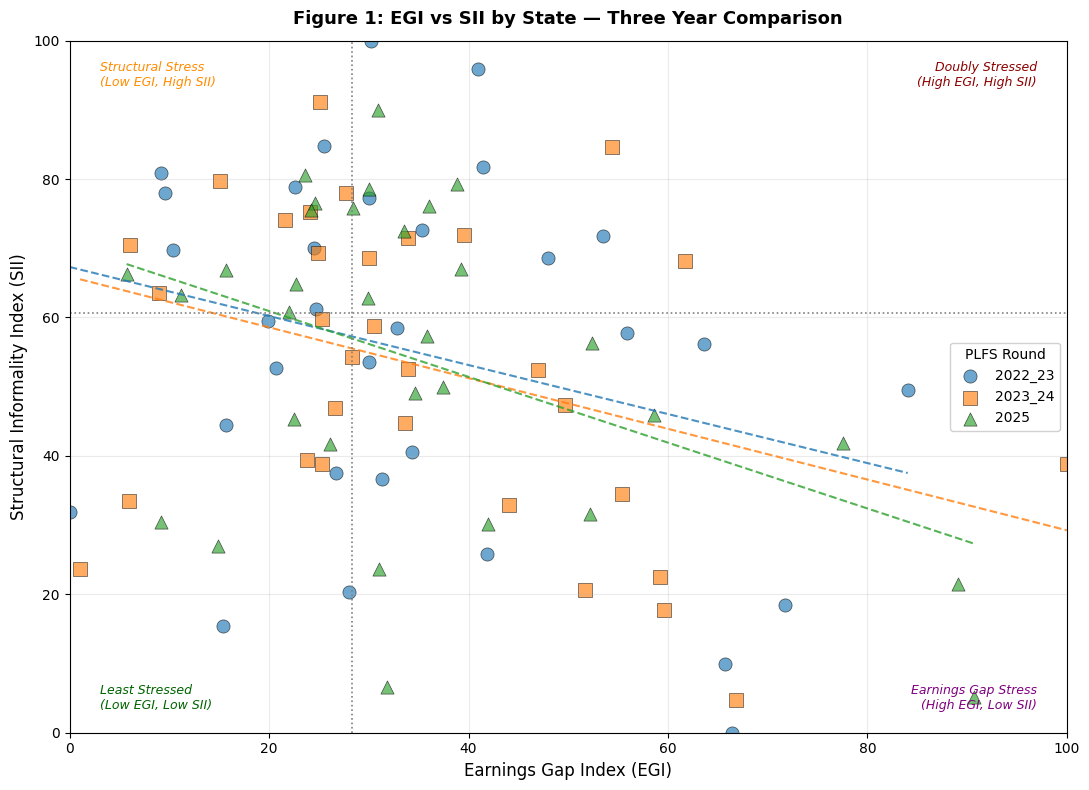

Saved: egi_sii_trendlines.png


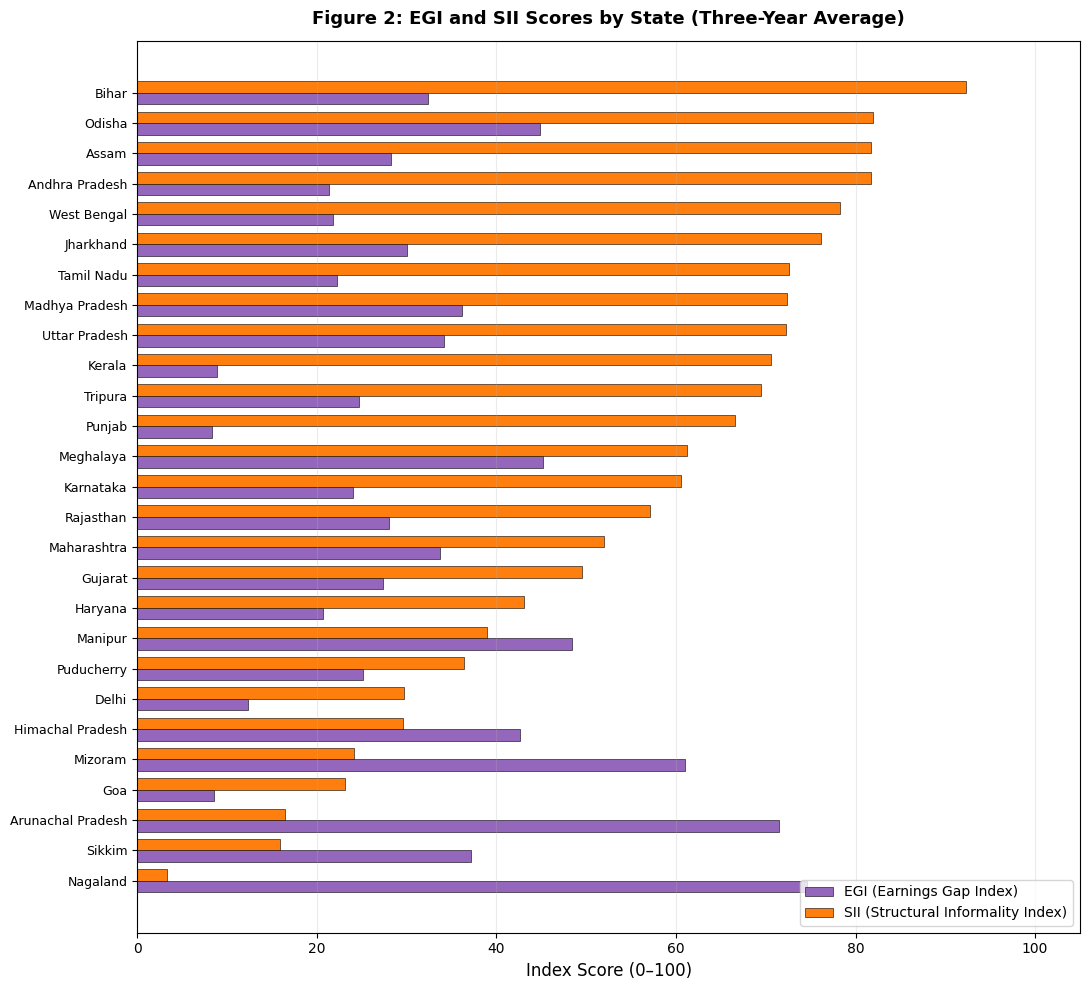

Saved: egi_sii_bars.png


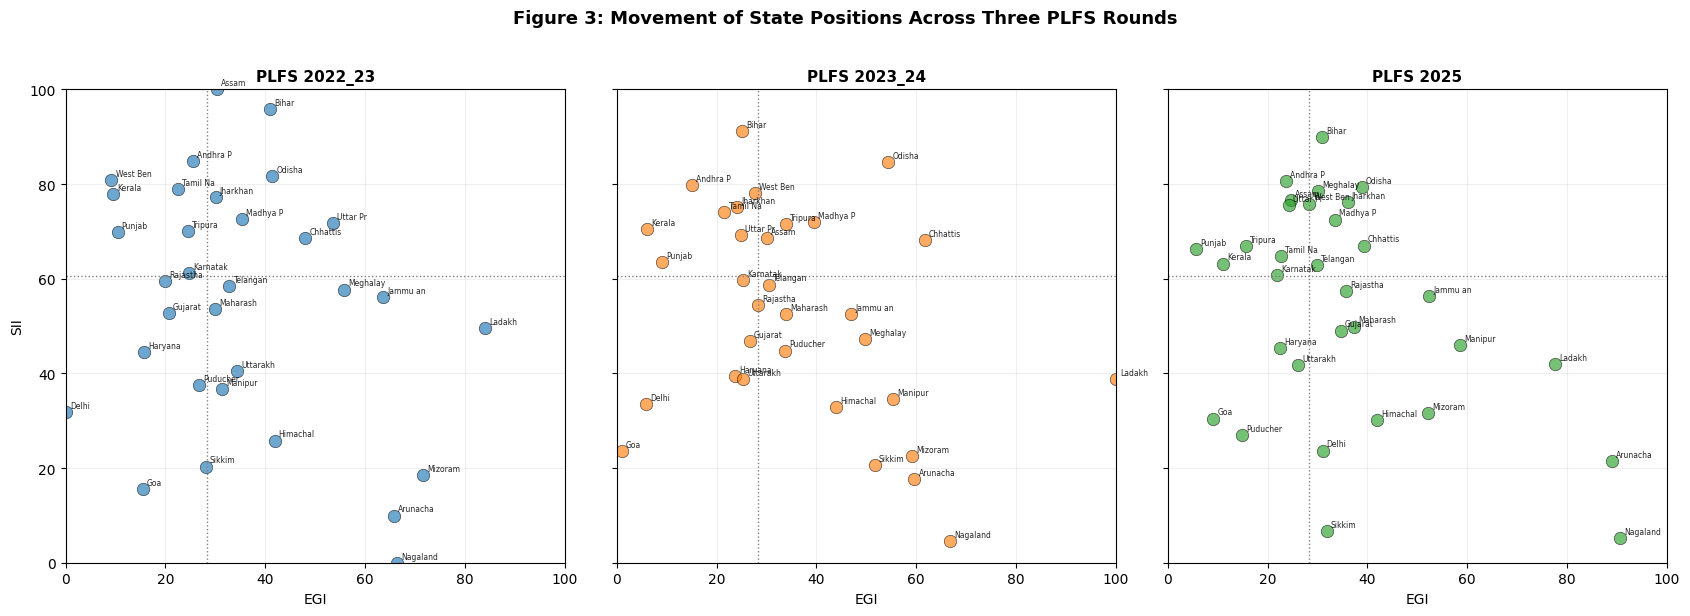

Saved: egi_sii_by_year.png

DONE. Files saved to C:\Projects\PLFS


In [245]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr
import statsmodels.api as sm
import os

BASE = r"C:\Projects\PLFS"

# ── BUILD STATE_AVG_CLEAN USING YOUR ACTUAL VARIABLE NAMES ───────────
# df_index has: state, year, EGI, SII
# df has: state, year, literacy, agri_share (merged in cells 26 and 32)

# Step 1: Average EGI and SII per state
state_avg = df_index.groupby('state').agg({
    'EGI': 'mean',
    'SII': 'mean'
}).reset_index()

# Step 2: Add literacy and agri_share from df
for col in ['literacy', 'agri_share']:
    if col in df.columns:
        tmp = df.groupby('state')[col].mean().reset_index()
        state_avg = state_avg.merge(tmp, on='state', how='left')
    else:
        print(f"WARNING: {col} not in df — check cells 26 and 32 ran")

# Step 3: Add urban_share
urban_rates = {
    'Andhra Pradesh': 29.6, 'Arunachal Pradesh': 22.7,
    'Assam': 14.1, 'Bihar': 11.3, 'Chhattisgarh': 23.2,
    'Delhi': 97.5, 'Goa': 62.2, 'Gujarat': 42.6,
    'Haryana': 34.9, 'Himachal Pradesh': 10.0,
    'Jammu & Kashmir': 27.4, 'Jammu and Kashmir': 27.4,
    'Jharkhand': 24.1, 'Karnataka': 38.6, 'Kerala': 47.7,
    'Madhya Pradesh': 27.6, 'Maharashtra': 45.2,
    'Manipur': 30.2, 'Meghalaya': 20.1, 'Mizoram': 52.1,
    'Nagaland': 28.9, 'Odisha': 16.7, 'Punjab': 37.5,
    'Rajasthan': 24.9, 'Sikkim': 25.2, 'Tamil Nadu': 48.4,
    'Telangana': 38.9, 'Tripura': 26.2,
    'Uttar Pradesh': 22.3, 'Uttarakhand': 30.2,
    'West Bengal': 31.9, 'Puducherry': 68.3, 'Ladakh': 28.0
}
urban_df = pd.DataFrame(list(urban_rates.items()),
                         columns=['state', 'urban_share'])
state_avg = state_avg.merge(urban_df, on='state', how='left')

# Step 4: Add GVA per capita
pop_dict = {
    'Andhra Pradesh': 492.4, 'Arunachal Pradesh': 13.8,
    'Assam': 312.1, 'Bihar': 1040.9, 'Chhattisgarh': 255.5,
    'Delhi': 167.5, 'Goa': 14.6, 'Gujarat': 604.4,
    'Haryana': 253.5, 'Himachal Pradesh': 68.6,
    'Jammu & Kashmir': 125.4, 'Jammu and Kashmir': 125.4,
    'Jharkhand': 329.9, 'Karnataka': 610.1, 'Kerala': 333.4,
    'Madhya Pradesh': 724.6, 'Maharashtra': 1123.7,
    'Manipur': 28.6, 'Meghalaya': 29.7, 'Mizoram': 10.9,
    'Nagaland': 19.8, 'Odisha': 419.7, 'Punjab': 277.4,
    'Rajasthan': 685.2, 'Sikkim': 6.1, 'Tamil Nadu': 721.5,
    'Telangana': 350.0, 'Tripura': 36.7,
    'Uttar Pradesh': 1998.1, 'Uttarakhand': 100.9,
    'West Bengal': 912.8, 'Puducherry': 12.5, 'Ladakh': 2.7
}

gva_raw = pd.read_excel(
    os.path.join(BASE, "gva.xlsx"),
    sheet_name="T_26(ii)", header=None)
rows = gva_raw.values.tolist()
gva_data = []
for row in rows[6:50]:
    state = row[1]
    if not isinstance(state, str):
        continue
    if any(x in str(state) for x in
           ['Source', 'Note', '---', 'State', 'Union']):
        continue
    vals = [float(v) for v in row[2:8]
            if isinstance(v, (int, float)) and not pd.isna(v)]
    if vals:
        gva_data.append({
            'state': state.replace('*', '').strip(),
            'gva_avg': np.mean(vals)
        })

gva_df = pd.DataFrame(gva_data)
gva_df['pop'] = gva_df['state'].map(pop_dict)
gva_df['gva_per_capita'] = gva_df['gva_avg'] / gva_df['pop']
state_avg = state_avg.merge(
    gva_df[['state', 'gva_per_capita']],
    on='state', how='left')

# Step 5: Standardise GVA and drop missing
state_avg['gva_pc_std'] = (
    (state_avg['gva_per_capita'] -
     state_avg['gva_per_capita'].mean()) /
     state_avg['gva_per_capita'].std()
)

state_avg_clean = state_avg.dropna(
    subset=['EGI', 'SII', 'literacy', 'agri_share',
            'urban_share', 'gva_pc_std']
).copy()

print(f"state_avg_clean: N = {len(state_avg_clean)} states")
print(f"Columns: {state_avg_clean.columns.tolist()}")


# ── TABLE 1: DESCRIPTIVE STATISTICS ──────────────────────────────────
print("\n" + "="*60)
print("TABLE 1: DESCRIPTIVE STATISTICS")
print("="*60)

desc = state_avg_clean[
    ['EGI', 'SII', 'literacy', 'agri_share',
     'urban_share', 'gva_per_capita']
].describe().T[['mean', 'std', 'min', 'max']].round(2)

desc.index = [
    'EGI (Earnings Gap Index, 0-100)',
    'SII (Structural Informality Index, 0-100)',
    'Literacy Rate (%)',
    'Agricultural Employment Share (%)',
    'Urban Population Share (%)',
    'GVA per Capita (₹ lakh, constant prices)'
]

print(desc.to_string())

pearson_r = state_avg_clean[['EGI', 'SII']].corr().iloc[0, 1]
spearman_r, spearman_p = spearmanr(
    state_avg_clean['EGI'], state_avg_clean['SII'])
print(f"\nNote: EGI-SII Pearson r = {pearson_r:+.3f}, "
      f"Spearman ρ = {spearman_r:+.3f} (p = {spearman_p:.4f})")

desc.to_csv(os.path.join(BASE, "table1_descriptive_stats.csv"))
print("Saved: table1_descriptive_stats.csv")


# ── FIGURE 1: EGI vs SII SCATTER WITH QUADRANTS + TRENDLINES ─────────
fig, ax = plt.subplots(figsize=(11, 8))

years = sorted(df_index['year'].unique())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']

for yr, color, marker in zip(years, colors, markers):
    yr_data = df_index[
        df_index['year'] == yr].dropna(subset=['EGI', 'SII'])
    ax.scatter(yr_data['EGI'], yr_data['SII'],
               label=str(yr), color=color, alpha=0.65,
               s=90, edgecolor='black', linewidth=0.5,
               marker=marker)
    z = np.polyfit(yr_data['EGI'], yr_data['SII'], 1)
    x_range = np.linspace(yr_data['EGI'].min(),
                           yr_data['EGI'].max(), 100)
    ax.plot(x_range, np.poly1d(z)(x_range),
            color=color, linestyle='--',
            linewidth=1.5, alpha=0.8)

egi_med = state_avg_clean['EGI'].median()
sii_med = state_avg_clean['SII'].median()
ax.axhline(sii_med, color='gray', linestyle=':', linewidth=1.2)
ax.axvline(egi_med, color='gray', linestyle=':', linewidth=1.2)

ax.text(0.97, 0.97, 'Doubly Stressed\n(High EGI, High SII)',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9, color='darkred', style='italic')
ax.text(0.03, 0.97, 'Structural Stress\n(Low EGI, High SII)',
        transform=ax.transAxes, ha='left', va='top',
        fontsize=9, color='darkorange', style='italic')
ax.text(0.97, 0.03, 'Earnings Gap Stress\n(High EGI, Low SII)',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, color='purple', style='italic')
ax.text(0.03, 0.03, 'Least Stressed\n(Low EGI, Low SII)',
        transform=ax.transAxes, ha='left', va='bottom',
        fontsize=9, color='darkgreen', style='italic')

ax.set_xlabel('Earnings Gap Index (EGI)', fontsize=12)
ax.set_ylabel('Structural Informality Index (SII)', fontsize=12)
ax.set_title(
    'Figure 1: EGI vs SII by State — Three Year Comparison',
    fontsize=13, fontweight='bold', pad=12)
ax.legend(title='PLFS Round', framealpha=0.9, fontsize=10)
ax.grid(True, alpha=0.25)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'egi_sii_trendlines.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: egi_sii_trendlines.png")


# ── FIGURE 2: SIDE-BY-SIDE BAR CHART ─────────────────────────────────
state_sorted = state_avg_clean.sort_values('SII', ascending=True)

fig, ax = plt.subplots(figsize=(11, 10))
y_pos = np.arange(len(state_sorted))
width = 0.38

ax.barh(y_pos - width/2, state_sorted['EGI'], width,
        label='EGI (Earnings Gap Index)',
        color='#9467bd', edgecolor='black', linewidth=0.4)
ax.barh(y_pos + width/2, state_sorted['SII'], width,
        label='SII (Structural Informality Index)',
        color='#ff7f0e', edgecolor='black', linewidth=0.4)

ax.set_yticks(y_pos)
ax.set_yticklabels(state_sorted['state'], fontsize=9)
ax.set_xlabel('Index Score (0–100)', fontsize=12)
ax.set_title(
    'Figure 2: EGI and SII Scores by State (Three-Year Average)',
    fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, axis='x', alpha=0.25)
ax.set_xlim(0, 105)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'egi_sii_bars.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: egi_sii_bars.png")


# ── FIGURE 3: THREE-PANEL SCATTER BY YEAR ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6),
                          sharex=True, sharey=True)

for ax, yr, color in zip(axes, years, colors):
    yr_data = df_index[
        df_index['year'] == yr].dropna(subset=['EGI', 'SII'])
    ax.scatter(yr_data['EGI'], yr_data['SII'],
               color=color, alpha=0.65, s=80,
               edgecolor='black', linewidth=0.5)
    for _, row in yr_data.iterrows():
        ax.annotate(str(row['state'])[:8],
                    (row['EGI'], row['SII']),
                    fontsize=5.5, alpha=0.85,
                    xytext=(3, 3), textcoords='offset points')
    ax.axhline(sii_med, color='gray', linestyle=':', linewidth=1)
    ax.axvline(egi_med, color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'PLFS {yr}', fontsize=11, fontweight='bold')
    ax.set_xlabel('EGI', fontsize=10)
    ax.grid(True, alpha=0.2)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)

axes[0].set_ylabel('SII', fontsize=10)
fig.suptitle(
    'Figure 3: Movement of State Positions Across Three PLFS Rounds',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'egi_sii_by_year.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("Saved: egi_sii_by_year.png")

print("\n" + "="*60)
print("DONE. Files saved to C:\\Projects\\PLFS")
print("="*60)